#      Applied Quantitative Economics Project: Goldsmiths, University of London

In [166]:
student_ID_number = 33936537

Total Project Word Count: 3970

#      Project 1: Regional Inequalities and Determinants of Spending by Secondary Schools in the UK 

## Introduction

Key Stage 4 (KS4) marks the final two years of secondary education in England for pupils aged 14 to 16, leading to GCSE examinations. Because this stage is a crucial determinant of future career paths, understanding the factors associated with school expenditure is vital for effective educational policy. School spending covers various categories, including teaching staff, catering, and learning resources. These patterns are often influenced by school size, location, and total income.
The analysis investigates the extent of regional inequalities in secondary school spending and the recent evolution of total gross expenditure at the national level. It seeks to identify the key economic factors that act as determinants of these expenditure patterns to better understand how resources are allocated across the country. The goal is to provide an economic rationale for these patterns and offer evidence-based suggestions for policy.

### Packages

In [270]:
# Install packages (run this only for the very first time):

install.packages(  "readxl"          ,  repos = "http://cran.r-project.org"  )
install.packages(  "htmlwidgets"     ,  repos = "http://cran.r-project.org"  )
install.packages(  "rpivotTable"     ,  repos = "http://cran.r-project.org"  )
install.packages(  "dplyr"           ,  repos = "http://cran.r-project.org"  )
install.packages(  "plyr"            ,  repos = "http://cran.r-project.org"  )
install.packages(  "tidyr"           ,  repos = "http://cran.r-project.org"  )
install.packages(  "ggplot2"         ,  repos = "http://cran.r-project.org"  )
install.packages(  "sjPlot"          ,  repos = "http://cran.r-project.org"  )
install.packages(  "huxtable"        ,  repos = "http://cran.r-project.org"  )
install.packages(  "jtools"          ,  repos = "http://cran.r-project.org"  )


The downloaded binary packages are in
	/var/folders/zv/k6svhk2533bgwvzltprcv3p40000gn/T//RtmpY0ZTjQ/downloaded_packages

The downloaded binary packages are in
	/var/folders/zv/k6svhk2533bgwvzltprcv3p40000gn/T//RtmpY0ZTjQ/downloaded_packages


Warning message:
“package ‘rpivotTable’ is not available for this version of R

A version of this package for your version of R might be available elsewhere,
see the ideas at
https://cran.r-project.org/doc/manuals/r-patched/R-admin.html#Installing-packages”



The downloaded binary packages are in
	/var/folders/zv/k6svhk2533bgwvzltprcv3p40000gn/T//RtmpY0ZTjQ/downloaded_packages

The downloaded binary packages are in
	/var/folders/zv/k6svhk2533bgwvzltprcv3p40000gn/T//RtmpY0ZTjQ/downloaded_packages

The downloaded binary packages are in
	/var/folders/zv/k6svhk2533bgwvzltprcv3p40000gn/T//RtmpY0ZTjQ/downloaded_packages


Warning message in download.file(urls, destfiles, "libcurl", mode = "wb", ...):
“downloaded length 4781433 != reported length 8489530”
Warning message in download.file(urls, destfiles, "libcurl", mode = "wb", ...):
“URL 'http://cran.r-project.org/bin/macosx/big-sur-arm64/contrib/4.5/ggplot2_4.0.2.tgz': Timeout of 60 seconds was reached”


Error in download.file(urls, destfiles, "libcurl", mode = "wb", ...) : 
  download from 'http://cran.r-project.org/bin/macosx/big-sur-arm64/contrib/4.5/ggplot2_4.0.2.tgz' failed


Warning message in download.packages(pkgs, destdir = tmpd, available = available, :
“download of package ‘ggplot2’ failed”



The downloaded binary packages are in
	/var/folders/zv/k6svhk2533bgwvzltprcv3p40000gn/T//RtmpY0ZTjQ/downloaded_packages

The downloaded binary packages are in
	/var/folders/zv/k6svhk2533bgwvzltprcv3p40000gn/T//RtmpY0ZTjQ/downloaded_packages

The downloaded binary packages are in
	/var/folders/zv/k6svhk2533bgwvzltprcv3p40000gn/T//RtmpY0ZTjQ/downloaded_packages


In [1]:
# Load packages every time R is run:

library(readxl)
library(rpivotTable)
library(dplyr)
library(ggplot2) 
library(sjPlot)
library(tidyr)
library(huxtable)
library(jtools)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘sjPlot’


The following object is masked from ‘package:ggplot2’:

    set_theme



Attaching package: ‘huxtable’


The following object is masked from ‘package:sjPlot’:

    font_size


The following object is masked from ‘package:ggplot2’:

    theme_grey


The following object is masked from ‘package:dplyr’:

    add_rownames




In [2]:
# Set R options

options(scipen=999)           # Drop scientific notation and use decimals
options(width = 200)          # Increase the width to display more columns
options(tibble.width = Inf)   # To show all columns of a tibble


In [3]:
# Set the working directory
folder = "/Users/truman/Desktop/Jupyter Lab/"    

setwd(folder)

In [4]:
# Make sure you are in the correct folder:
getwd()

[1] "/Users/truman/Desktop/Jupyter Lab"

In [5]:
# List the files in the working directory
dir() |> print()

 [1] "33936537 - AppliedQE Project.ipynb"                                  "Applied QE - Complete R code for Jupyter notebook - Version 9.ipynb"
 [3] "AppQE_project_sample - Full Sample (758 schools).xlsx"               "AppQE_project_sample.xlsx"                                          
 [5] "AppQE_TS_project_01.xlsx"                                            "AppQE_TS_project_02.xlsx"                                           
 [7] "AQE_Week6.ipynb"                                                     "moving_plot.gif"                                                    
 [9] "ONS_UKEA_GDP_Expenditure_and_Deflators.xlsx"                         "ONS_UKEA_GDP_Expenditure_CP_NSA_GBPm.xlsx"                          
[11] "UKDS_LCFS_sample_01.xlsx"                                            "UKDS_LCFS_sample_02.xlsx"                                           
[13] "UKDS_LFS_sample_01.xlsx"                                             "Week8_lab.ipynb"                                      

In [59]:
# Initial Sample Data Set
Project_Sample_758 = read_excel("AppQE_project_sample - Full Sample (758 schools).xlsx", sheet = "data") 

# Create variables from the data frame columns:
attach(Project_Sample_758) 

The following object is masked _by_ .GlobalEnv:

    REGION


The following objects are masked from AppQE_project_sample (pos = 3):

    ATT8SCR, DLONDON, DMIXED, EXP, EXPLRESP, EXPP, GENDER, INC, INCP, ISPOST16, ISPRIMARY, ISSECONDARY, LANAME, LAPAY, PENGFL, PFSM, PSEN, PUP, PUPKS4, RATPUPTEA, REGION, SCHNAME,
    SHEXPLRES, SHSELFINC, SUR, SURP, TEA, URN, WTEA


The following objects are masked from AppQE_project_sample (pos = 4):

    ATT8SCR, DLONDON, DMIXED, EXP, EXPLRESP, EXPP, GENDER, INC, INCP, ISPOST16, ISPRIMARY, ISSECONDARY, LANAME, LAPAY, PENGFL, PFSM, PSEN, PUP, PUPKS4, RATPUPTEA, REGION, SCHNAME,
    SHEXPLRES, SHSELFINC, SUR, SURP, TEA, URN, WTEA


The following objects are masked from Project_Sample_758 (pos = 6):

    ATT8SCR, DLONDON, DMIXED, EXP, EXPLRESP, EXPP, GENDER, INC, INCP, ISPOST16, ISPRIMARY, ISSECONDARY, LANAME, LAPAY, PENGFL, PFSM, PSEN, PUP, PUPKS4, RATPUPTEA, REGION, SCHNAME,
    SHEXPLRES, SHSELFINC, SUR, SURP, TEA, URN, WTEA




## Dataset Properties

This study is a cross-sectional dataset sourced from the UK Department for Education (DfE), specifically the "Revised key stage 4 results" for the 2016-2017 academic and fiscal year. This dataset integrates student achievement metrics with detailed school-level financial workforce data, allowing for a multifaceted analysis of the English secondary education landscape. The main variables that will be observed throughout this project include EXPP, EXP, PUP, REGION, PFSM, RATPUPTEA, INCP, SURP, and DLONDON.

### Scope and Units of Analysis

The primary sample comprises 758 observations, where each unit of analysis represents an individual "maintained" school. Maintained schools are defined as government-funded institutions managed by a local authority. It is a critical distinction that while the English secondary education system includes academies, independent schools, and special schools, this analysis is restricted to maintained institutions to ensure a degree of comparability regarding funding structures and local authority constraints. 

### Key Variables for Financial and Regional Analysis

To evaluate the extent of regional inequalities (Question I) and identify the determinants of expenditure (Question III),  variables have been selected based on their economic and structural relevance

The variable "REGION" is central to the analysis, as it categorizes schools into nine distinct English regions. This enables the calculation of group averages and the identification of spatial concentration tendencies. Additionally, "DLONDON" is utilized to isolate the "London effect," accounting for the specific economic pressures and higher labor costs associated with the capital.

To facilitate an equitable comparison between schools of varying sizes, normalizing expenditure metrics is essential for comparison. The analysis prioritizes EXPP. EXPP reveals the actual resource allocation per student, providing a more accurate measurement of financial disparity.

The analysis of spending evolution over time utilizes a secondary dataset covering the national-level period from 1999/00 to 2016/17. This file includes a time series of total gross expenditure and funding, alongside an economy-wide price index. This index enables an assessment of whether school funding has maintained its purchasing power against inflationary pressures over the nearly two-decade period.

### Full Dataset

In [7]:
Project_Sample_758

URN,SCHNAME,LANAME,REGION,GENDER,ISSECONDARY,PUP,PUPKS4,PSEN,PFSM,⋯,EXPP,SURP,EXPLRESP,SHEXPLRES,SHSELFINC,ATT8SCR,DMIXED,ISPRIMARY,ISPOST16,DLONDON
<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
100049,Haverstock School,Camden,07_London,Mixed,1,1227,199,3.5,39.7,⋯,8731,75,249,2.851907,0.9311833,38.4,1,0,1,1
100050,Parliament Hill School,Camden,07_London,Girls,1,1114,172,1.4,22.9,⋯,7694,73,405,5.263842,4.6478692,55.2,0,0,1,1
100051,Regent High School,Camden,07_London,Mixed,1,831,110,4.0,39.3,⋯,9391,322,221,2.353317,7.3406774,39.4,1,0,1,1
100052,Hampstead School,Camden,07_London,Mixed,1,1205,201,2.7,22.1,⋯,8083,-177,480,5.938389,1.8340501,45.1,1,0,1,1
100053,Acland Burghley School,Camden,07_London,Mixed,1,974,160,5.2,24.3,⋯,8428,-18,613,7.273374,2.1521998,51.2,1,0,1,1
100054,The Camden School for Girls,Camden,07_London,Girls,1,1006,110,1.1,13.3,⋯,6787,60,380,5.598939,7.1126041,63.5,0,0,1,1
100055,Maria Fidelis Roman Catholic Convent School FCJ,Camden,07_London,Mixed,1,627,78,2.5,34.6,⋯,8351,-8,313,3.748054,1.7020257,45.8,1,0,1,1
100056,William Ellis School,Camden,07_London,Boys,1,858,117,2.0,23.0,⋯,7966,-307,691,8.674366,5.1442747,47.6,0,0,1,1
100059,La Sainte Union Catholic Secondary School,Camden,07_London,Girls,1,1134,176,0.6,15.9,⋯,6773,-14,341,5.034697,1.1540169,54.1,0,0,1,1


### Variable Abbreviation Guide

| Abbreviation | Description |
| :--- | :--- |
| **URN** | School Unique Reference Number |
| **SCHNAME** | School Name |
| **LANAME** | School Local Authority |
| **REGION** | School region in England |
| **GENDER** | Gender of student body (Mixed, Boys, Girls) |
| **ISSECONDARY** | Whether the school is offering secondary education (1 = Yes, 0 = No) |
| **PUP** | Number of full-time equivalent (FTE) pupils |
| **PUPKS4** | Number of pupils at the end of key stage 4 |
| **PSEN** | Percentage of Special Education Needs pupils (% of pupils) |
| **PFSM** | Percentage of pupils eligible for Free School Meals (% of pupils) |
| **PENGFL** | Percentage pupils with English as first language (% of pupils) |
| **RATPUPTEA** | Pupil:Teacher Ratio (number of pupils per teacher) |
| **TEA** | Number of full-time equivalent (FTE) teachers |
| **WTEA** | Mean gross FTE salary of a teacher (£ per year) |
| **LAPAY** | Median gross weekly pay in the Local Authority (£ per week) |
| **INC** | School Income (grant funding and self generated) (£) |
| **EXP** | School Expenditure (all categories) (£) |
| **SUR** | School Surplus (£ per year) |
| **INCP** | School Income per Pupil (£ per pupil) |
| **EXPP** | School Expenditure per Pupil (£ per pupil) |
| **SURP** | School Surplus per Pupil (£ per pupil) |
| **EXPLRESP** | School Expenditure in Learning Resources per Pupil (£ per pupil) |
| **SHEXPLRES** | Share of School Expenditure in Learning Resources (% of Total) |
| **SHSELFINC** | Share of Self-generated School Income (% of Total) |
| **ATT8SCR** | Average Attainment 8 Score per Pupil |
| **DMIXED** | Whether it is a mixed-gender school (1 = Yes) |
| **ISPRIMARY** | Whether the school is offering primary education (1 = Yes, 0 = No) |
| **ISPOST16** | Whether the school is offering 16–18 education (1 = Yes, 0 = No) |
| **DLONDON** | Whether the School is located in the London region (1 = Yes, 0 = No) |

## Question 1: Regional Inequalities

In this section, we investigate various variables and understand their impact on EXPP. Multiple metrics will be utilized to investigate the inequalities, including pivot tables, box plots, double bar charts, and histograms.

In [8]:
# Select the variables for the data frame, Question 1
data_frame = data.frame(URN, SCHNAME, LANAME, REGION, DLONDON, EXP, EXPP, EXPLRESP, SHEXPLRES, WTEA, PFSM, PSEN, PUP, LAPAY, DLONDON)               

In [9]:
dim(data_frame)                                        # Dimensions of the data frame (rows by columns)

[1] 758  15

In [10]:
# Data frames filtered by region

data_frame_North_East    = filter(data_frame, REGION=="01_North_East")
data_frame_North_West  = filter(data_frame, REGION=="02_North_West")
data_frame_Yorkshire_Humberside    = filter(data_frame, REGION=="03_Yorkshire_Humberside")
data_frame_East_Midlands    = filter(data_frame, REGION=="04_East_Midlands")
data_frame_West_Midlands    = filter(data_frame, REGION=="05_West_Midlands")
data_frame_East_of_England   = filter(data_frame, REGION=="06_East_of_England")
data_frame_London    = filter(data_frame, REGION=="07_London")
data_frame_South_East   = filter(data_frame, REGION=="08_South_East")
data_frame_South_West    = filter(data_frame, REGION=="09_South_West")

In [11]:
# Data frame for North East
data_frame_North_East

URN,SCHNAME,LANAME,REGION,DLONDON,EXP,EXPP,EXPLRESP,SHEXPLRES,WTEA,PFSM,PSEN,PUP,LAPAY,DLONDON.1
<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
108410,Kingsmeadow Community Comprehensive School,Gateshead,01_North_East,0,4714090,8170,374,4.577723,35482,35.9,1.5,577,487.3,0
108524,Walbottle Campus,Newcastle upon Tyne,01_North_East,0,10476320,6388,366,5.729493,37023,22.4,0.8,1640,508.8,0
108531,Heaton Manor School,Newcastle upon Tyne,01_North_East,0,10761600,5605,245,4.371097,39249,18.0,0.9,1920,508.8,0
108627,Marden High School,North Tyneside,01_North_East,0,3933204,5478,158,2.884264,40775,7.9,0.8,718,514.8,0
108628,Norham High School,North Tyneside,01_North_East,0,3457740,10230,395,3.861193,38547,34.1,7.1,338,514.8,0
108638,Whitley Bay High School,North Tyneside,01_North_East,0,8665954,5423,208,3.835515,39701,3.1,1.8,1598,514.8,0
108639,George Stephenson High School,North Tyneside,01_North_East,0,6253200,5400,250,4.629630,39667,12.7,1.9,1158,514.8,0
108640,Burnside Business and Enterprise College,North Tyneside,01_North_East,0,7231040,6128,271,4.422324,39823,16.9,2.1,1180,514.8,0
108641,Churchill Community College,North Tyneside,01_North_East,0,6432151,8657,520,6.006700,38750,18.0,1.3,743,514.8,0


In [12]:
# Data frame for North West
data_frame_North_West

URN,SCHNAME,LANAME,REGION,DLONDON,EXP,EXPP,EXPLRESP,SHEXPLRES,WTEA,PFSM,PSEN,PUP,LAPAY,DLONDON.1
<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
104688,Holly Lodge Girls' College,Liverpool,02_North_West,0,5365140,7260,172,2.369146,41807,36.9,0.1,739,496.6,0
104692,Fazakerley High School,Liverpool,02_North_West,0,5745684,6559,203,3.094984,40562,23.8,0.7,876,496.6,0
104693,Alsop High School Technology & Applied Learning Specialist College,Liverpool,02_North_West,0,11103201,6717,468,6.967396,39896,36.0,0.3,1653,496.6,0
104696,"Broadgreen International School, A Technology College",Liverpool,02_North_West,0,8257584,7269,447,6.149402,39716,56.0,2.3,1136,496.6,0
104698,Calderstones School,Liverpool,02_North_West,0,8620928,6016,184,3.058511,39468,16.7,0.4,1433,496.6,0
104700,Gateacre School,Liverpool,02_North_West,0,8063328,7098,280,3.944773,32628,31.3,1.0,1136,496.6,0
104703,King David High School,Liverpool,02_North_West,0,3556971,5673,279,4.918033,36307,2.3,1.8,627,496.6,0
104705,Archbishop Blanch School,Liverpool,02_North_West,0,5242482,5589,239,4.276257,38690,14.2,0.7,938,496.6,0
104706,Notre Dame Catholic College,Liverpool,02_North_West,0,6496281,7291,320,4.388973,41990,31.5,0.2,891,496.6,0


In [13]:
# Data frame for Yorkshire Humberside
data_frame_Yorkshire_Humberside

URN,SCHNAME,LANAME,REGION,DLONDON,EXP,EXPP,EXPLRESP,SHEXPLRES,WTEA,PFSM,PSEN,PUP,LAPAY,DLONDON.1
<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
106653,Penistone Grammar School,Barnsley,03_Yorkshire_Humberside,0,7542960,4744,358,7.546374,39033,4.0,1.7,1590,476.8,0
106962,Saint Pius X Catholic High School A Specialist School in Humanities,Rotherham,03_Yorkshire_Humberside,0,3764593,5873,305,5.193257,39065,12.0,1.7,641,485.2,0
107395,Titus Salt School,Bradford,03_Yorkshire_Humberside,0,8336016,5694,239,4.197401,40308,15.4,2.2,1464,471.6,0
107413,Carlton Bolling College,Bradford,03_Yorkshire_Humberside,0,9003489,6171,352,5.704100,38884,25.1,0.5,1459,471.6,0
107428,The Holy Family Catholic School,Bradford,03_Yorkshire_Humberside,0,5510868,6036,333,5.516899,41215,12.5,1.8,913,471.6,0
107562,"Calder High School, The Calder Learning Trust",Calderdale,03_Yorkshire_Humberside,0,6477996,5748,280,4.871260,36898,9.0,0.9,1127,522.1,0
107564,Todmorden High School,Calderdale,03_Yorkshire_Humberside,0,3664872,5358,254,4.740575,35134,13.9,2.0,684,522.1,0
107756,Netherhall Learning Campus High School,Kirklees,03_Yorkshire_Humberside,0,3938480,7574,310,4.092950,35964,36.6,2.7,520,494.4,0
107758,Almondbury Community School,Kirklees,03_Yorkshire_Humberside,0,4399488,6432,247,3.840174,41134,35.8,1.7,684,494.4,0


In [14]:
# Data frame for East Midlands
data_frame_East_Midlands

URN,SCHNAME,LANAME,REGION,DLONDON,EXP,EXPP,EXPLRESP,SHEXPLRES,WTEA,PFSM,PSEN,PUP,LAPAY,DLONDON.1
<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
112932,Chapel-en-le-Frith High School,Derbyshire,04_East_Midlands,0,5976916,6413,126,1.964759,41060,7.1,5.6,932,517.5,0
112936,New Mills School,Derbyshire,04_East_Midlands,0,3388810,6218,205,3.296880,40941,10.7,2.8,545,517.5,0
112938,William Allitt School,Derbyshire,04_East_Midlands,0,5144589,5893,548,9.299169,39749,8.9,2.0,873,517.5,0
112939,Aldercar High School,Derbyshire,04_East_Midlands,0,4049982,6338,298,4.701799,44853,22.6,7.4,639,517.5,0
112949,Tibshelf Community School,Derbyshire,04_East_Midlands,0,5095656,6088,493,8.097898,38357,13.7,4.6,837,517.5,0
112950,Highfields School,Derbyshire,04_East_Midlands,0,6577851,5309,183,3.446977,38455,9.1,2.3,1239,517.5,0
112951,The Bemrose School,Derby,04_East_Midlands,0,6419500,6940,301,4.337176,37021,23.8,3.5,925,551.6,0
112956,Littleover Community School,Derby,04_East_Midlands,0,7397509,4249,191,4.495175,42197,5.5,0.8,1741,551.6,0
112957,Glossopdale School,Derbyshire,04_East_Midlands,0,6370416,6474,180,2.780352,41416,11.1,2.8,984,517.5,0


In [15]:
# Data frame for West Midlands
data_frame_West_Midlands

URN,SCHNAME,LANAME,REGION,DLONDON,EXP,EXPP,EXPLRESP,SHEXPLRES,WTEA,PFSM,PSEN,PUP,LAPAY,DLONDON.1
<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
103483,Hodge Hill Girls' School,Birmingham,05_West_Midlands,0,4693500,6258,326,5.2093321,39381,13.6,0.7,750,495.0,0
103486,Kings Heath Boys,Birmingham,05_West_Midlands,0,4209915,7869,266,3.3803533,37909,31.3,1.1,535,495.0,0
103493,Bordesley Green Girls' School & Sixth Form,Birmingham,05_West_Midlands,0,5984550,6435,330,5.1282051,39941,19.9,4.0,930,495.0,0
103497,Queensbridge School,Birmingham,05_West_Midlands,0,5220412,6833,376,5.5027074,37946,18.9,3.4,764,495.0,0
103498,Selly Park Girls' School,Birmingham,05_West_Midlands,0,4999060,7330,258,3.5197817,39888,30.8,0.7,682,495.0,0
103499,Turves Green Girls' School,Birmingham,05_West_Midlands,0,3756970,6685,165,2.4682124,41313,30.1,1.1,562,495.0,0
103500,Turves Green Boys' School,Birmingham,05_West_Midlands,0,3698640,7472,497,6.6514989,38956,31.3,1.3,495,495.0,0
103501,Wheelers Lane Technology College,Birmingham,05_West_Midlands,0,4298235,6989,257,3.6772070,39881,18.9,1.5,615,495.0,0
103503,Hodge Hill College,Birmingham,05_West_Midlands,0,8164892,6844,508,7.4225599,35722,34.9,0.7,1193,495.0,0


In [16]:
# Data frame for East of England
data_frame_East_of_England

URN,SCHNAME,LANAME,REGION,DLONDON,EXP,EXPP,EXPLRESP,SHEXPLRES,WTEA,PFSM,PSEN,PUP,LAPAY,DLONDON.1
<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
109669,Sandy Secondary School,Central Bedfordshire,06_East_of_England,0,3419752,6184,311,5.029107,38022,6.9,1.5,553,590.9,0
109686,Lealands High School,Luton,06_East_of_England,0,6018624,6966,298,4.277921,38198,18.8,1.7,864,504.0,0
109690,Biddenham International School and Sports College,Bedford,06_East_of_England,0,5826891,6629,391,5.898326,37598,17.8,2.3,879,584.0,0
109707,Ashcroft High School,Luton,06_East_of_England,0,7117319,6047,331,5.473789,36673,22.4,0.5,1177,504.0,0
109709,Lea Manor High School Performing Arts College,Luton,06_East_of_England,0,7370068,6557,437,6.664633,39019,21.4,3.2,1124,504.0,0
109713,Stopsley High School,Luton,06_East_of_England,0,5881347,6057,398,6.570910,39490,15.5,2.3,971,504.0,0
110882,Ken Stimpson Community School,Peterborough,06_East_of_England,0,6241329,6137,243,3.959589,37712,14.9,1.1,1017,466.3,0
110907,St John Fisher Catholic High School,Peterborough,06_East_of_England,0,4745016,6702,343,5.117875,39992,14.8,2.0,708,466.3,0
115237,De La Salle School and Language College,Essex,06_East_of_England,0,4291872,5792,263,4.540746,39718,13.9,4.5,741,594.0,0


In [17]:
# Data frame for London
data_frame_London 

URN,SCHNAME,LANAME,REGION,DLONDON,EXP,EXPP,EXPLRESP,SHEXPLRES,WTEA,PFSM,PSEN,PUP,LAPAY,DLONDON.1
<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
100049,Haverstock School,Camden,07_London,1,10712937,8731,249,2.851907,49579,39.7,3.5,1227,737.5,1
100050,Parliament Hill School,Camden,07_London,1,8571116,7694,405,5.263842,42520,22.9,1.4,1114,737.5,1
100051,Regent High School,Camden,07_London,1,7803921,9391,221,2.353317,43812,39.3,4.0,831,737.5,1
100052,Hampstead School,Camden,07_London,1,9740015,8083,480,5.938389,44444,22.1,2.7,1205,737.5,1
100053,Acland Burghley School,Camden,07_London,1,8208872,8428,613,7.273374,45657,24.3,5.2,974,737.5,1
100054,The Camden School for Girls,Camden,07_London,1,6827722,6787,380,5.598939,46798,13.3,1.1,1006,737.5,1
100055,Maria Fidelis Roman Catholic Convent School FCJ,Camden,07_London,1,5236077,8351,313,3.748054,48574,34.6,2.5,627,737.5,1
100056,William Ellis School,Camden,07_London,1,6834828,7966,691,8.674366,49514,23.0,2.0,858,737.5,1
100059,La Sainte Union Catholic Secondary School,Camden,07_London,1,7680582,6773,341,5.034697,47084,15.9,0.6,1134,737.5,1


In [18]:
# Data frame for South East
data_frame_South_East

URN,SCHNAME,LANAME,REGION,DLONDON,EXP,EXPP,EXPLRESP,SHEXPLRES,WTEA,PFSM,PSEN,PUP,LAPAY,DLONDON.1
<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
110048,The Willink School,West Berkshire,08_South_East,0,5408992,5216,266,5.099693,38257,3.0,1.8,1037,625.9,0
110060,The Emmbrook School,Wokingham,08_South_East,0,5491362,5113,193,3.774692,39172,5.8,1.8,1074,739.7,0
110062,The Bulmershe School,Wokingham,08_South_East,0,5595226,6062,241,3.975586,40097,12.0,3.2,923,739.7,0
110063,Little Heath School,West Berkshire,08_South_East,0,8288020,5020,246,4.900398,38732,7.5,1.5,1651,625.9,0
110068,Sandhurst School,Bracknell Forest,08_South_East,0,5101880,5206,134,2.573953,38028,5.5,1.5,980,609.3,0
110069,Garth Hill College,Bracknell Forest,08_South_East,0,9450401,5773,288,4.988741,36972,7.4,2.9,1637,609.3,0
110071,Easthampstead Park Community School,Bracknell Forest,08_South_East,0,4970628,6084,290,4.766601,38692,12.4,2.1,817,609.3,0
110078,Wexham School,Slough,08_South_East,0,6889500,7655,492,6.427172,39226,20.9,3.0,900,524.2,0
110084,St Bernard's Catholic Grammar School,Slough,08_South_East,0,4422012,5178,500,9.656238,38818,1.3,0.6,854,524.2,0


In [19]:
# Data frame for South West
data_frame_South_West

URN,SCHNAME,LANAME,REGION,DLONDON,EXP,EXPP,EXPLRESP,SHEXPLRES,WTEA,PFSM,PSEN,PUP,LAPAY,DLONDON.1
<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
109319,Brimsham Green School,South Gloucestershire,09_South_West,0,5781694,5846,222,3.797468,36015,7.0,3.2,989,549.8,0
109324,Chipping Sodbury School,South Gloucestershire,09_South_West,0,4347081,6291,212,3.369893,39074,5.8,3.5,691,549.8,0
109327,St Mary Redcliffe and Temple School,"Bristol, City of",09_South_West,0,8985192,5273,447,8.477148,39552,5.7,1.4,1704,524.0,0
109328,St Mark's CofE School,Bath and North East Somerset,09_South_West,0,1897983,9169,686,7.481732,38775,21.4,7.3,207,564.1,0
109329,Saint Gregory's Catholic College,Bath and North East Somerset,09_South_West,0,4844160,5220,507,9.712644,39879,5.9,1.4,928,564.1,0
109331,St Bernadette Catholic Secondary School,"Bristol, City of",09_South_West,0,4280640,5824,658,11.298077,39995,13.0,1.9,735,524.0,0
112041,Torpoint Community College,Cornwall,09_South_West,0,3806523,5957,248,4.163169,40676,9.6,1.4,639,467.6,0
112045,Budehaven Community School,Cornwall,09_South_West,0,6365600,5840,333,5.702055,39928,9.4,2.3,1090,467.6,0
112052,Poltair School,Cornwall,09_South_West,0,4004480,6257,284,4.538916,38489,22.3,2.3,640,467.6,0


### Histogram of EXPP by Region

For each region, a histogram will be made to understand the shape and distribution of EXPP within each region. Understanding where the mean lies and the skewness is important in understanding how each region works.

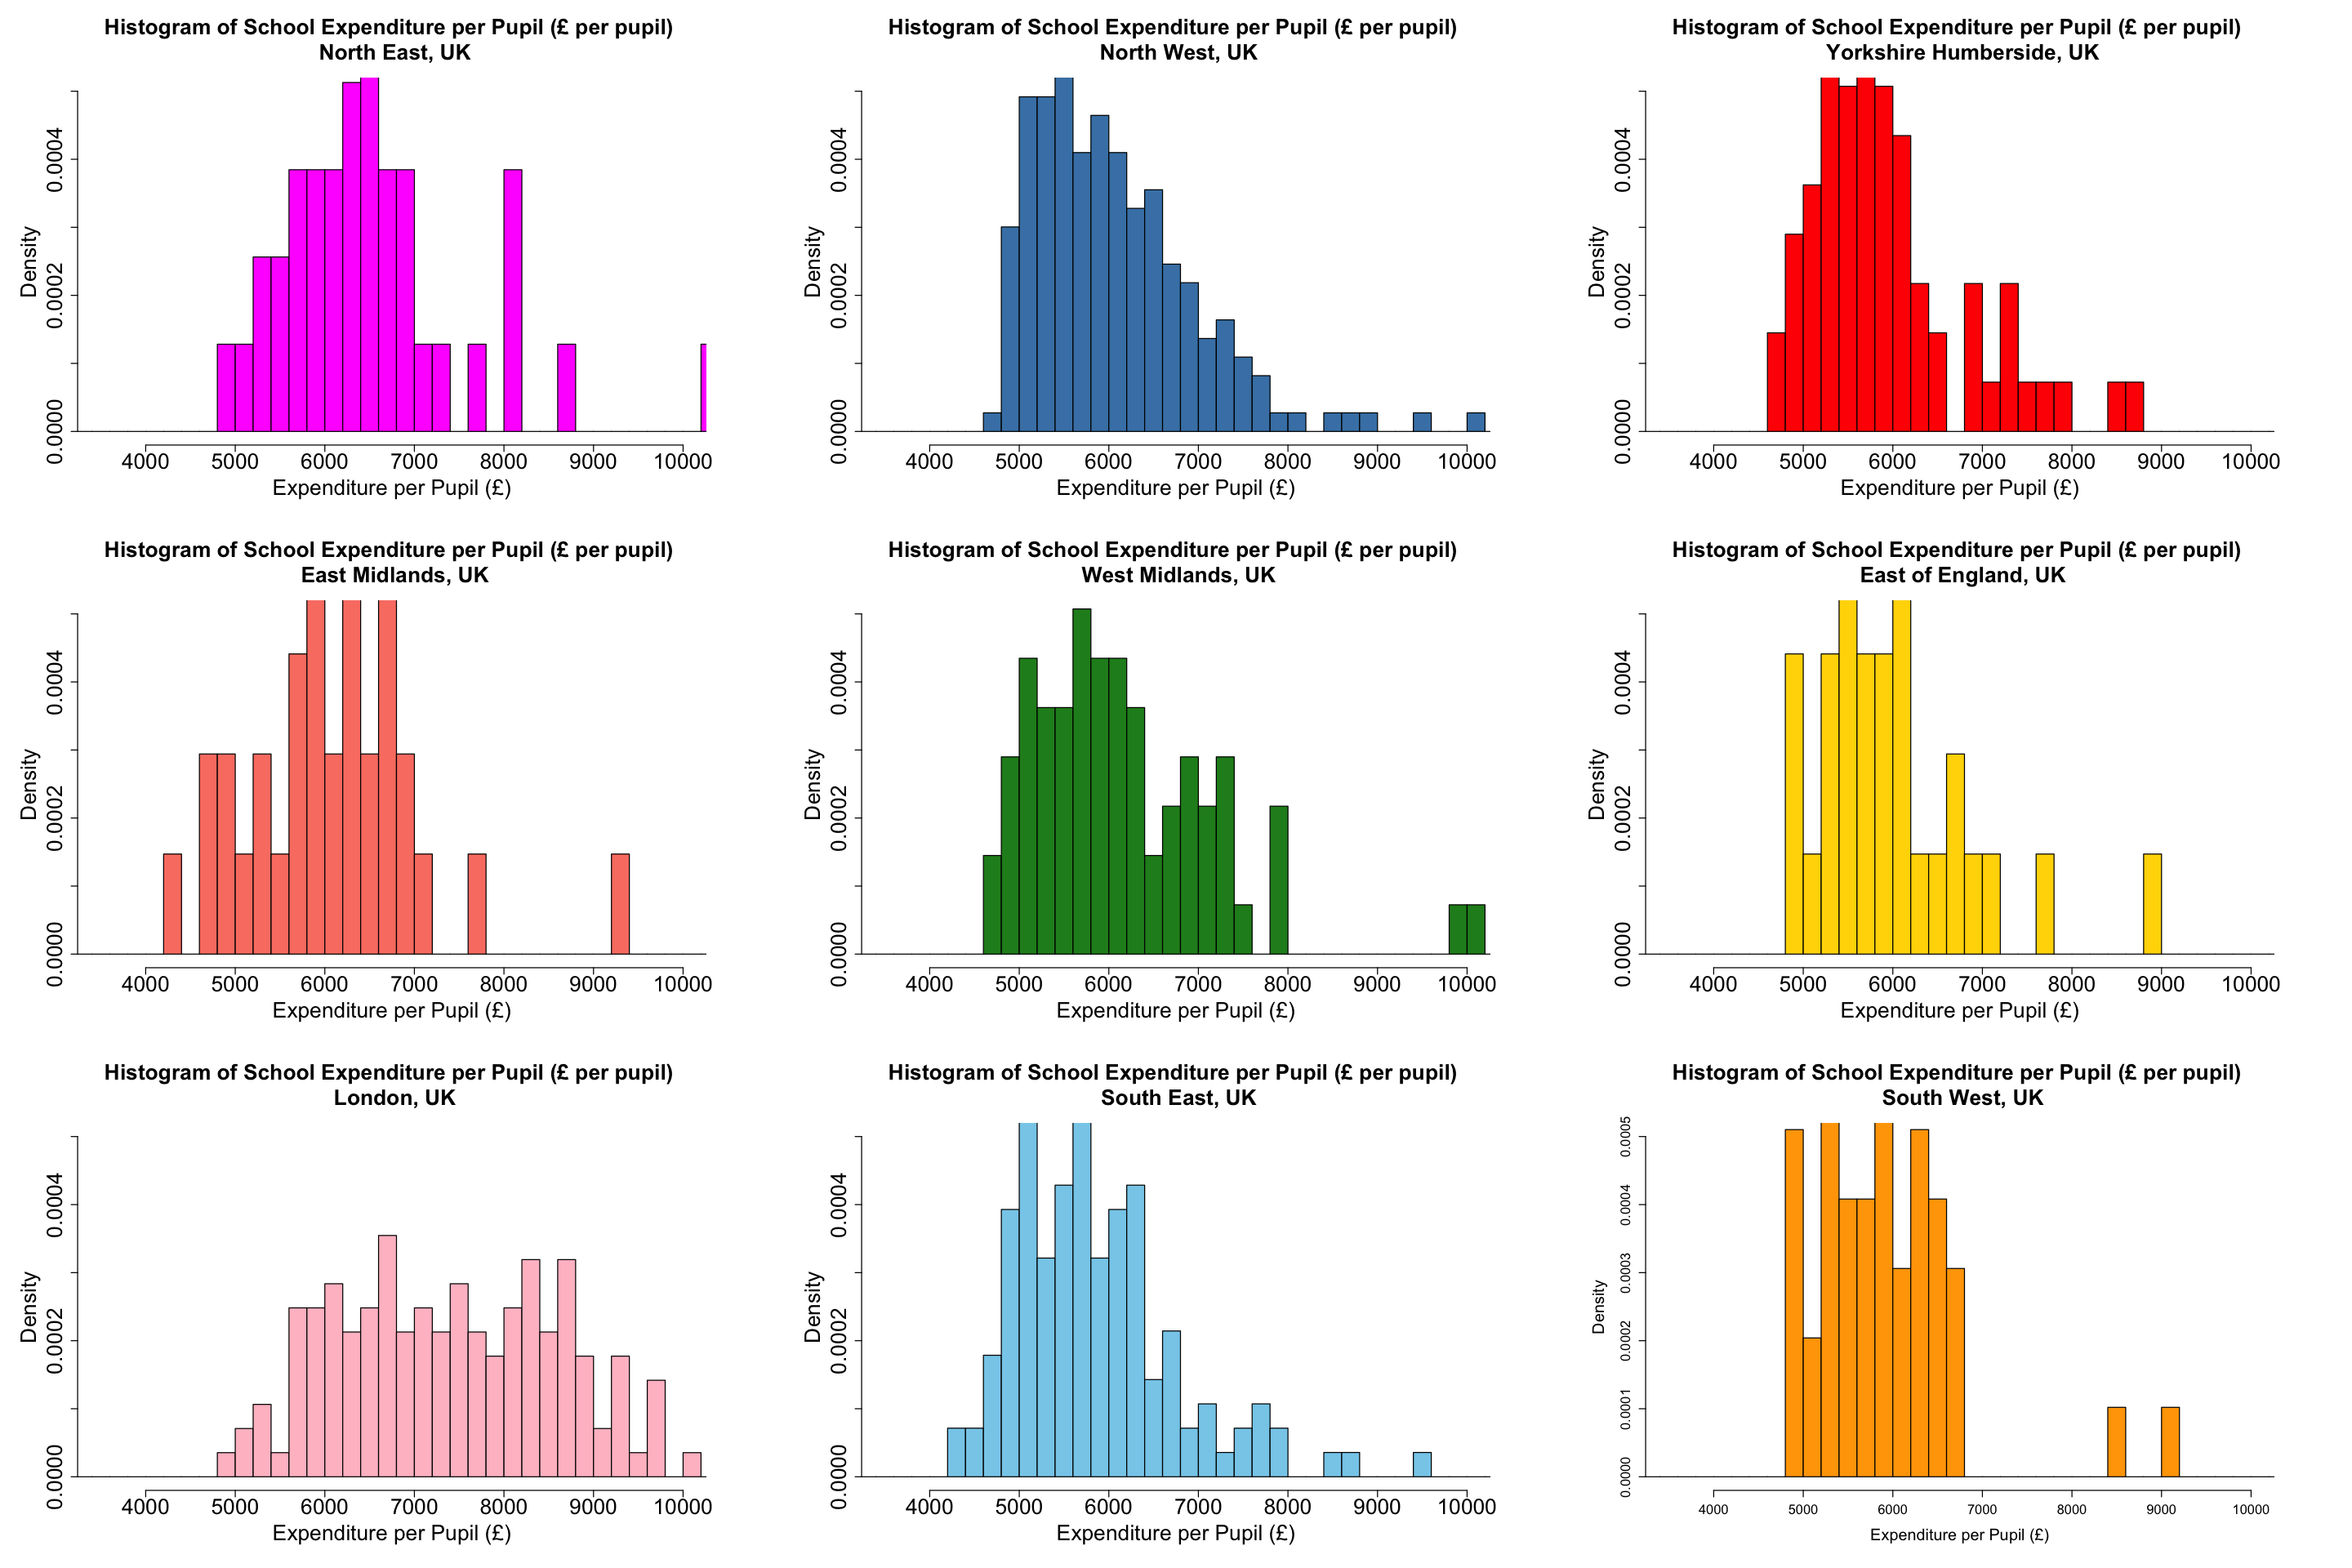

In [20]:
# Plot the histograms by Region (EXPP), School Expenditure per Pupil (£ per pupil)

# Plot size
options(repr.plot.width = 24, repr.plot.height = 16)

# 3 rows by 3 columns:
par( mfrow = c(3, 3) , mar=c(6,6,6,6) )


hist( data_frame_North_East$EXPP,   
                               main = "Histogram of School Expenditure per Pupil (£ per pupil) \n North East, UK",
                                col = "magenta",
                               xlab = "Expenditure per Pupil (£)",
                               ylab = "Density",
                             breaks = seq(3000, 14000, by = 200),          
                               xlim = c(3500, 10000),
                               ylim = c(0, 0.0005),
                               freq = FALSE,
                           cex.main = 2.0,                                 # Increase the size of the main title
                            cex.lab = 2,                                 # Increase the size of the x and y axis labels
                           cex.axis = 2)                                 # Increase the size of the axis tick labels


hist( data_frame_North_West$EXPP,   
                               main = "Histogram of School Expenditure per Pupil (£ per pupil) \n North West, UK",
                                col = "steelblue",
                               xlab = "Expenditure per Pupil (£)",
                               ylab = "Density",
                             breaks = seq(3000, 14000, by = 200),
                             xlim = c(3500, 10000),
                               ylim = c(0, 0.0005),
                               freq = FALSE,
                           cex.main = 2.0,                                
                            cex.lab = 2,                                
                           cex.axis = 2)                             

hist( data_frame_Yorkshire_Humberside$EXPP,   
                               main = "Histogram of School Expenditure per Pupil (£ per pupil) \n Yorkshire Humberside, UK",
                                col = "red",
                               xlab = "Expenditure per Pupil (£)",
                               ylab = "Density",
                             breaks = seq(3000, 14000, by = 200),
                             xlim = c(3500, 10000),
                               ylim = c(0, 0.0005),
                               freq = FALSE,
                           cex.main = 2.0,                                
                            cex.lab = 2,                               
                           cex.axis = 2)                          

hist( data_frame_East_Midlands$EXPP,   
                               main = "Histogram of School Expenditure per Pupil (£ per pupil) \n East Midlands, UK",
                                col = "salmon",
                               xlab = "Expenditure per Pupil (£)",
                               ylab = "Density",
                             breaks = seq(3000, 14000, by = 200),
                             xlim = c(3500, 10000),
                               ylim = c(0, 0.0005),
                               freq = FALSE,
                           cex.main = 2.0,                                
                            cex.lab = 2,                              
                           cex.axis = 2)                                

hist( data_frame_West_Midlands$EXPP,   
                               main = "Histogram of School Expenditure per Pupil (£ per pupil) \n West Midlands, UK",
                                col = "forest green",
                               xlab = "Expenditure per Pupil (£)",
                               ylab = "Density",
                             breaks = seq(3000, 14000, by = 200),
                             xlim = c(3500, 10000),
                               ylim = c(0, 0.0005),
                               freq = FALSE,
                           cex.main = 2.0,                               
                            cex.lab = 2,                                
                           cex.axis = 2)                               

hist( data_frame_East_of_England$EXPP,   
                               main = "Histogram of School Expenditure per Pupil (£ per pupil) \n East of England, UK",
                                col = "gold",
                               xlab = "Expenditure per Pupil (£)",
                               ylab = "Density",
                             breaks = seq(3000, 14000, by = 200),
                             xlim = c(3500, 10000),
                               ylim = c(0, 0.0005),
                               freq = FALSE,
                           cex.main = 2.0,                                
                            cex.lab = 2,                                
                           cex.axis = 2)                              

hist( data_frame_London$EXPP,   
                               main = "Histogram of School Expenditure per Pupil (£ per pupil) \n London, UK",
                                col = "pink",
                               xlab = "Expenditure per Pupil (£)",
                               ylab = "Density",
                             breaks = seq(3000, 14000, by = 200),
                             xlim = c(3500, 10000),
                               ylim = c(0, 0.0005),
                               freq = FALSE,
                           cex.main = 2.0,                              
                            cex.lab = 2,                              
                           cex.axis = 2)                                

hist( data_frame_South_East$EXPP,   
                               main = "Histogram of School Expenditure per Pupil (£ per pupil) \n South East, UK",
                                col = "sky blue",
                               xlab = "Expenditure per Pupil (£)",
                               ylab = "Density",
                             breaks = seq(3000, 14000, by = 200),
                             xlim = c(3500, 10000),
                               ylim = c(0, 0.0005),
                               freq = FALSE,
                           cex.main = 2.0,                               
                            cex.lab = 2,                               
                           cex.axis = 2)                                

hist( data_frame_South_West$EXPP,   
                               main = "Histogram of School Expenditure per Pupil (£ per pupil) \n South West, UK",
                                col = "orange",
                               xlab = "Expenditure per Pupil (£)",
                               ylab = "Density",
                             breaks = seq(3000, 14000, by = 200),
                             xlim = c(3500, 10000),
                               ylim = c(0, 0.0005),
                               freq = FALSE,
                           cex.main = 2.0,                              
                            cex.lab = 1.5,                               
                           cex.axis = 1.25)                               

The nine regional histograms reveal a standardized funding baseline, with most schools clustering between £5,500 and £6,000, though London’s distribution is shifted significantly to the right. Each region displays a unimodal, right-skewed shape, indicating that while most schools operate at a baseline, a minority of high-need institutions receive exceptional funding exceeding £10,000 per pupil. This skew reflects a non-linear funding formula designed to provide a "safety net" for schools with specialized requirements, such as high SEN concentrations or lack of economies of scale. Ultimately, the "London premium" and persistent outliers confirm that geography and socioeconomic intensity are the primary determinants of English school resource distribution.

### Double Bar Chart

This double bar chart examines the mechanical relationship between teacher pay (WTEA) and overall school funding (EXPP), treating salary as a primary driver of per-pupil expenditure. By visualizing these metrics together, the chart reveals how statutory regional pay scales function as baseline costs that pull spending upward in the capital. This comparison distinguishes between a surplus of educational resources and the functional requirement of operating within the UK's most expensive labor markets.

In [21]:
# Create the pivot table:

pivot_table_EXPP_0  =  data_frame |> 

                  group_by(   REGION   ) |> 

                  summarise(                         count = n(),
                                            average.EXPP = mean(EXPP),
                                            average.WTEA = mean(WTEA)  )   |>    
 
                    mutate(        relative.average.EXPP = ( average.EXPP / mean(EXPP) )*100,  
                                   relative.average.WTEA = ( average.WTEA / mean(WTEA) )*100,
                              diff.relative.average.EXPP = relative.average.EXPP - 100,  
                              diff.relative.average.WTEA = relative.average.WTEA - 100  )

In [22]:
pivot_table_sorted_diff_rel_avg_EXPP = pivot_table_EXPP_0  |>  arrange( desc( pivot_table_EXPP_0$diff.relative.average.EXPP ) )

In [23]:
pivot_table_sorted_diff_rel_avg_EXPP

REGION,count,average.EXPP,average.WTEA,relative.average.EXPP,relative.average.WTEA,diff.relative.average.EXPP,diff.relative.average.WTEA
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
07_London,141,7433.801,44295.51,118.23285,110.79013,18.2328481,10.7901303
01_North_East,39,6666.103,39420.23,106.02278,98.59628,6.0227800,-1.4037215
05_West_Midlands,69,6249.725,38946.29,99.40039,97.41088,-0.5996122,-2.5891232
02_North_West,183,6057.858,39668.23,96.34879,99.21656,-3.6512067,-0.7834371
04_East_Midlands,34,6047.029,39369.79,96.17657,98.47013,-3.8234317,-1.5298716
06_East_of_England,34,5940.294,39166.41,94.47897,97.96144,-5.5210312,-2.0385633
03_Yorkshire_Humberside,69,5922.014,38172.87,94.18824,95.47643,-5.8117643,-4.5235706
09_South_West,49,5891.469,39164.39,93.70242,97.95637,-6.2975769,-2.0436256
08_South_East,140,5807.393,38236.40,92.36521,95.63533,-7.6347942,-4.3646709


In [24]:
REGION                 = pivot_table_sorted_diff_rel_avg_EXPP$REGION
diff.relative.average.EXPP  = pivot_table_sorted_diff_rel_avg_EXPP$diff.relative.average.EXPP
diff.relative.average.WTEA = pivot_table_sorted_diff_rel_avg_EXPP$diff.relative.average.WTEA

data_for_barchart = data.frame(REGION,diff.relative.average.EXPP,diff.relative.average.WTEA)

In [25]:
data_for_barchart

REGION,diff.relative.average.EXPP,diff.relative.average.WTEA
<chr>,<dbl>,<dbl>
07_London,18.2328481,10.7901303
01_North_East,6.0227800,-1.4037215
05_West_Midlands,-0.5996122,-2.5891232
02_North_West,-3.6512067,-0.7834371
04_East_Midlands,-3.8234317,-1.5298716
06_East_of_England,-5.5210312,-2.0385633
03_Yorkshire_Humberside,-5.8117643,-4.5235706
09_South_West,-6.2975769,-2.0436256
08_South_East,-7.6347942,-4.3646709


In [26]:
# Combine Both Variables of data to be used in gplot as a single data frame for plotting
data_frame_for_plotting_1 = data.frame(
                                        Variable = "EXPP",
                                          REGION = data_for_barchart$REGION,
                                           Value = data_for_barchart$diff.relative.average.EXPP )


data_frame_for_plotting_2 = data.frame(
                                        Variable = "WTEA",
                                          REGION = data_for_barchart$REGION,
                                           Value = data_for_barchart$diff.relative.average.WTEA )


data_frame_for_plotting = rbind(data_frame_for_plotting_1,data_frame_for_plotting_2)

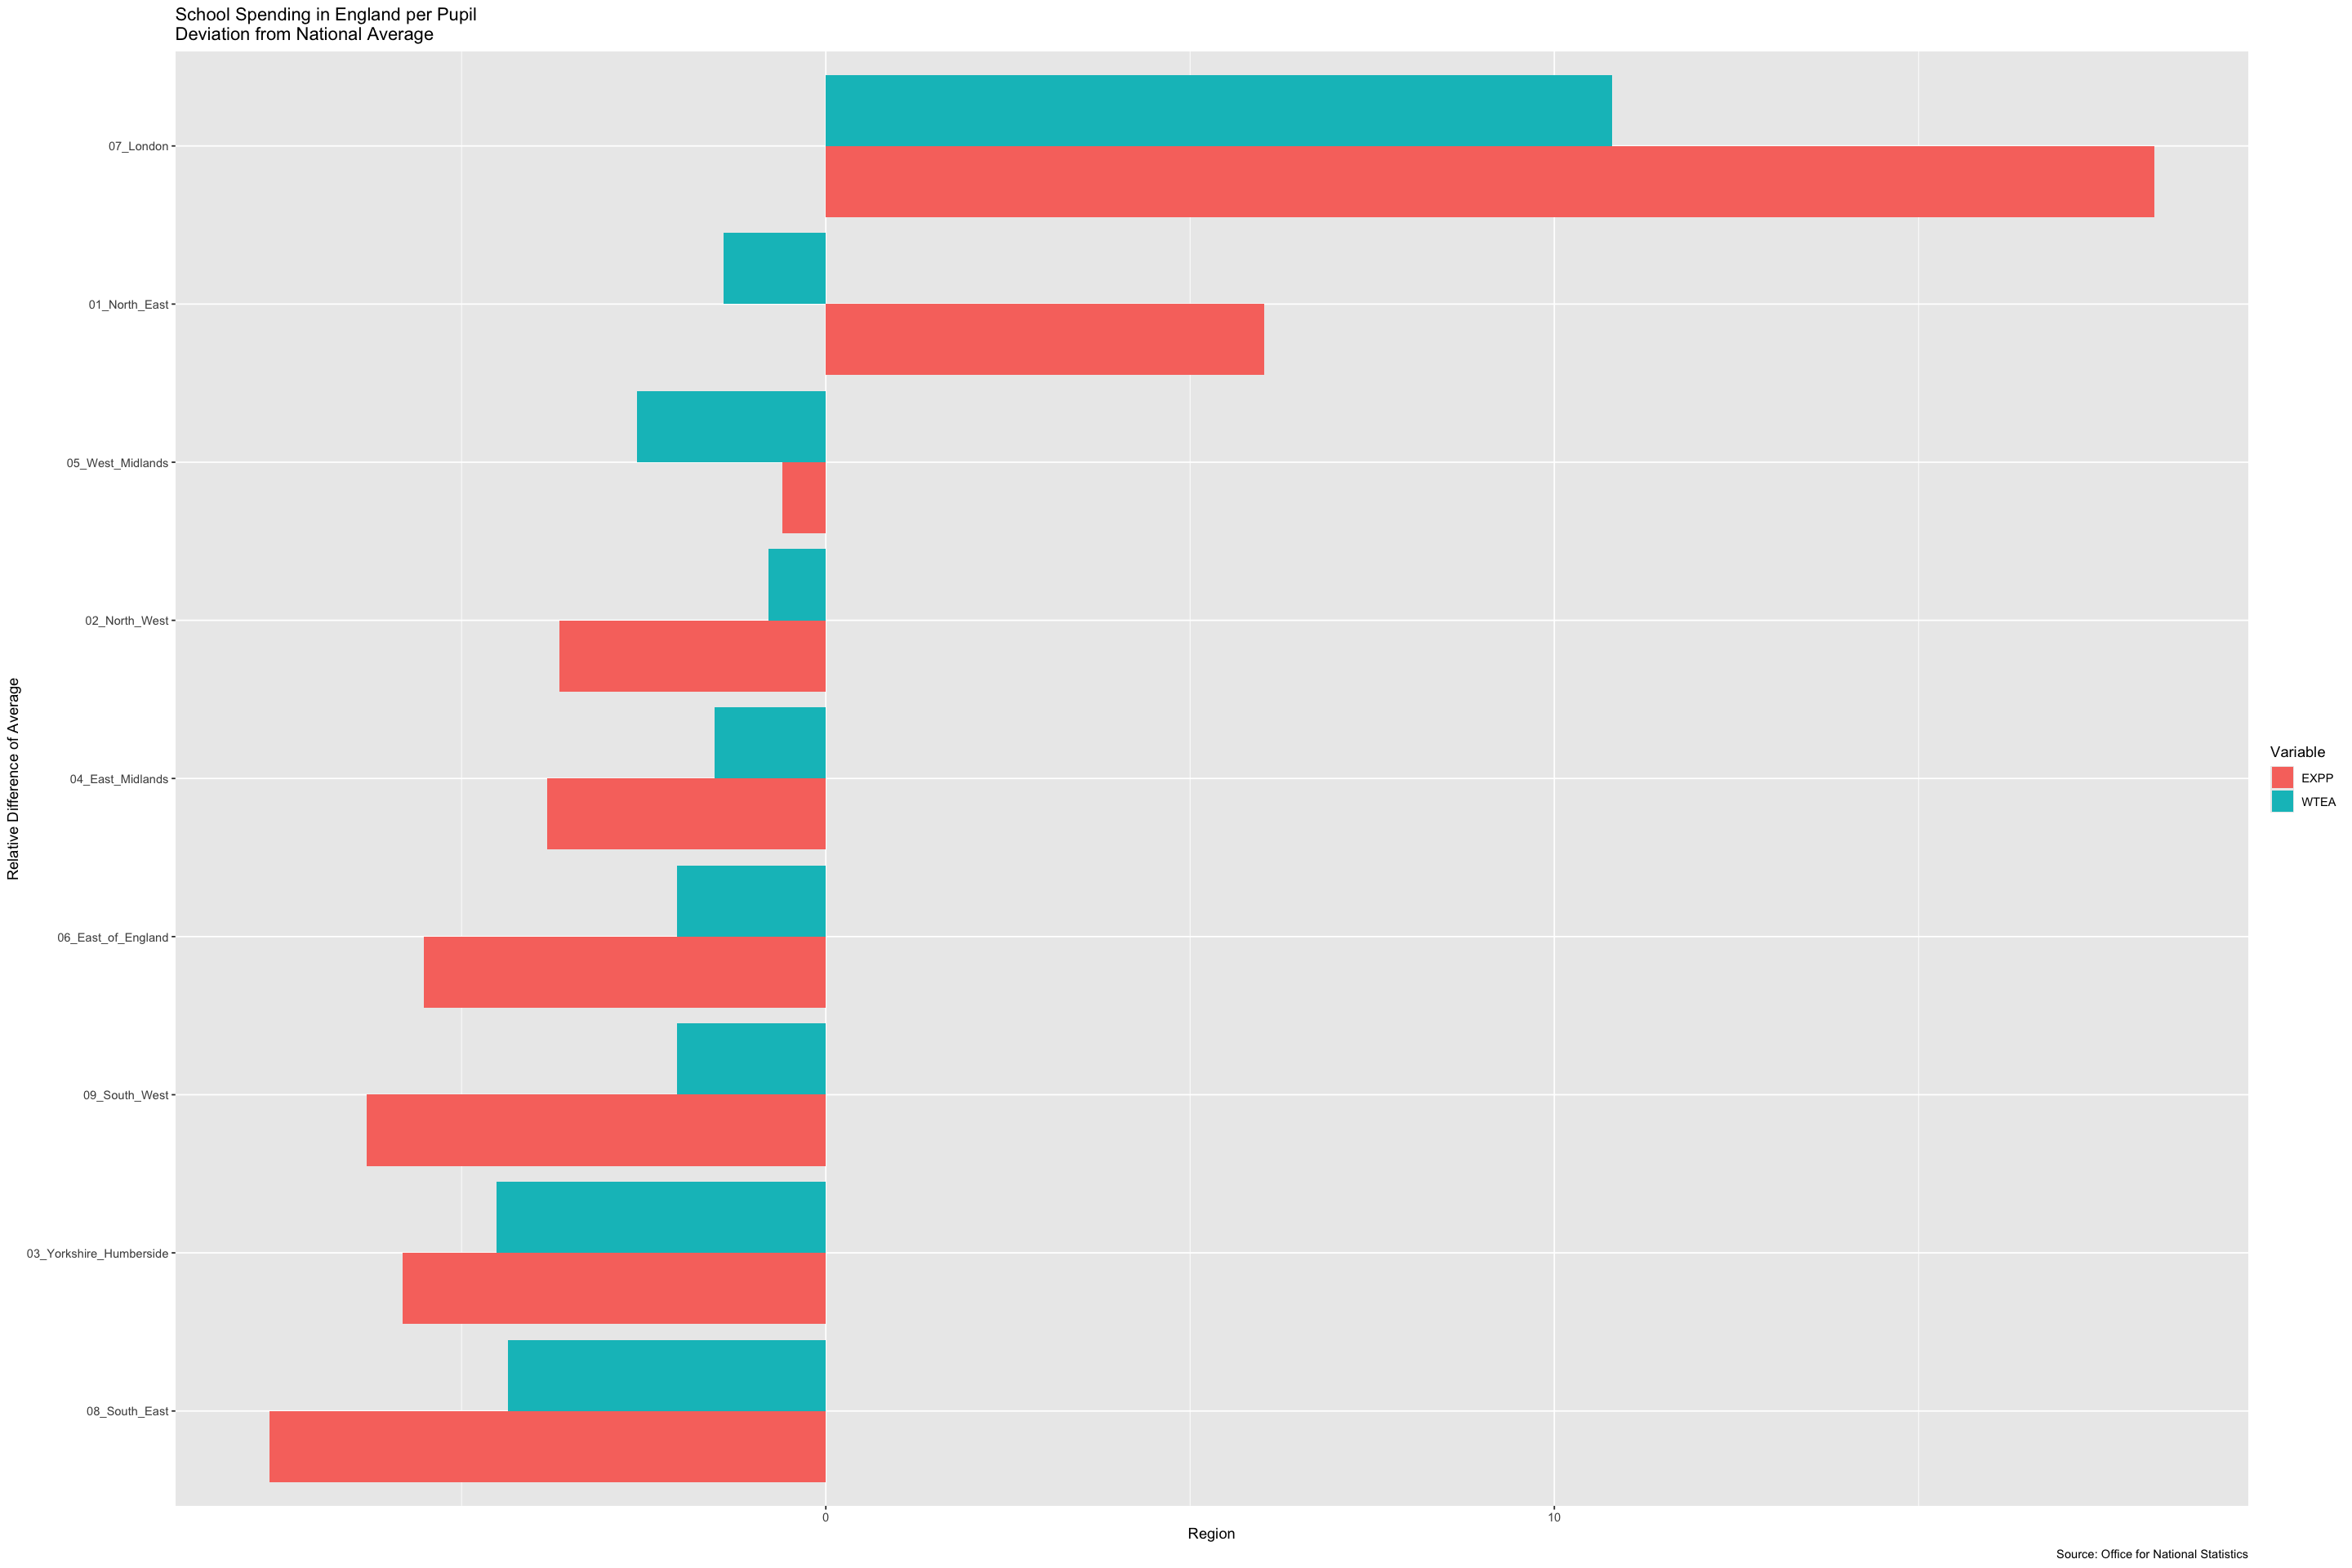

In [27]:
ggplot(
         data = data_frame_for_plotting, 
         aes(x = Value, y = reorder(REGION, +Value), fill = Variable)) +      
         geom_col(position = "dodge") +
         ggtitle("School Spending in England per Pupil \nDeviation from National Average") +                      # title
         labs(y="Relative Difference of Average", x="Region", caption="Source: Office for National Statistics")   # labels

The double bar chart illustrates regional deviations in EXPP and WTEA from the national average, identifying London as a significant outlier. The capital shows positive deviations of approximately 18% and 11%, respectively, quantifying the London weighting and Area Cost Adjustment required for the UK's most expensive labor market. Conversely, most other regions exhibit negative values, as their funding is tied to standard "Rest of England" pay scales that lack these extreme cost-of-living premiums. This visual gap confirms that geographic location dictates structural funding disparities compared to the national baseline.

### Boxplot and Historgram of EXPP as a Whole

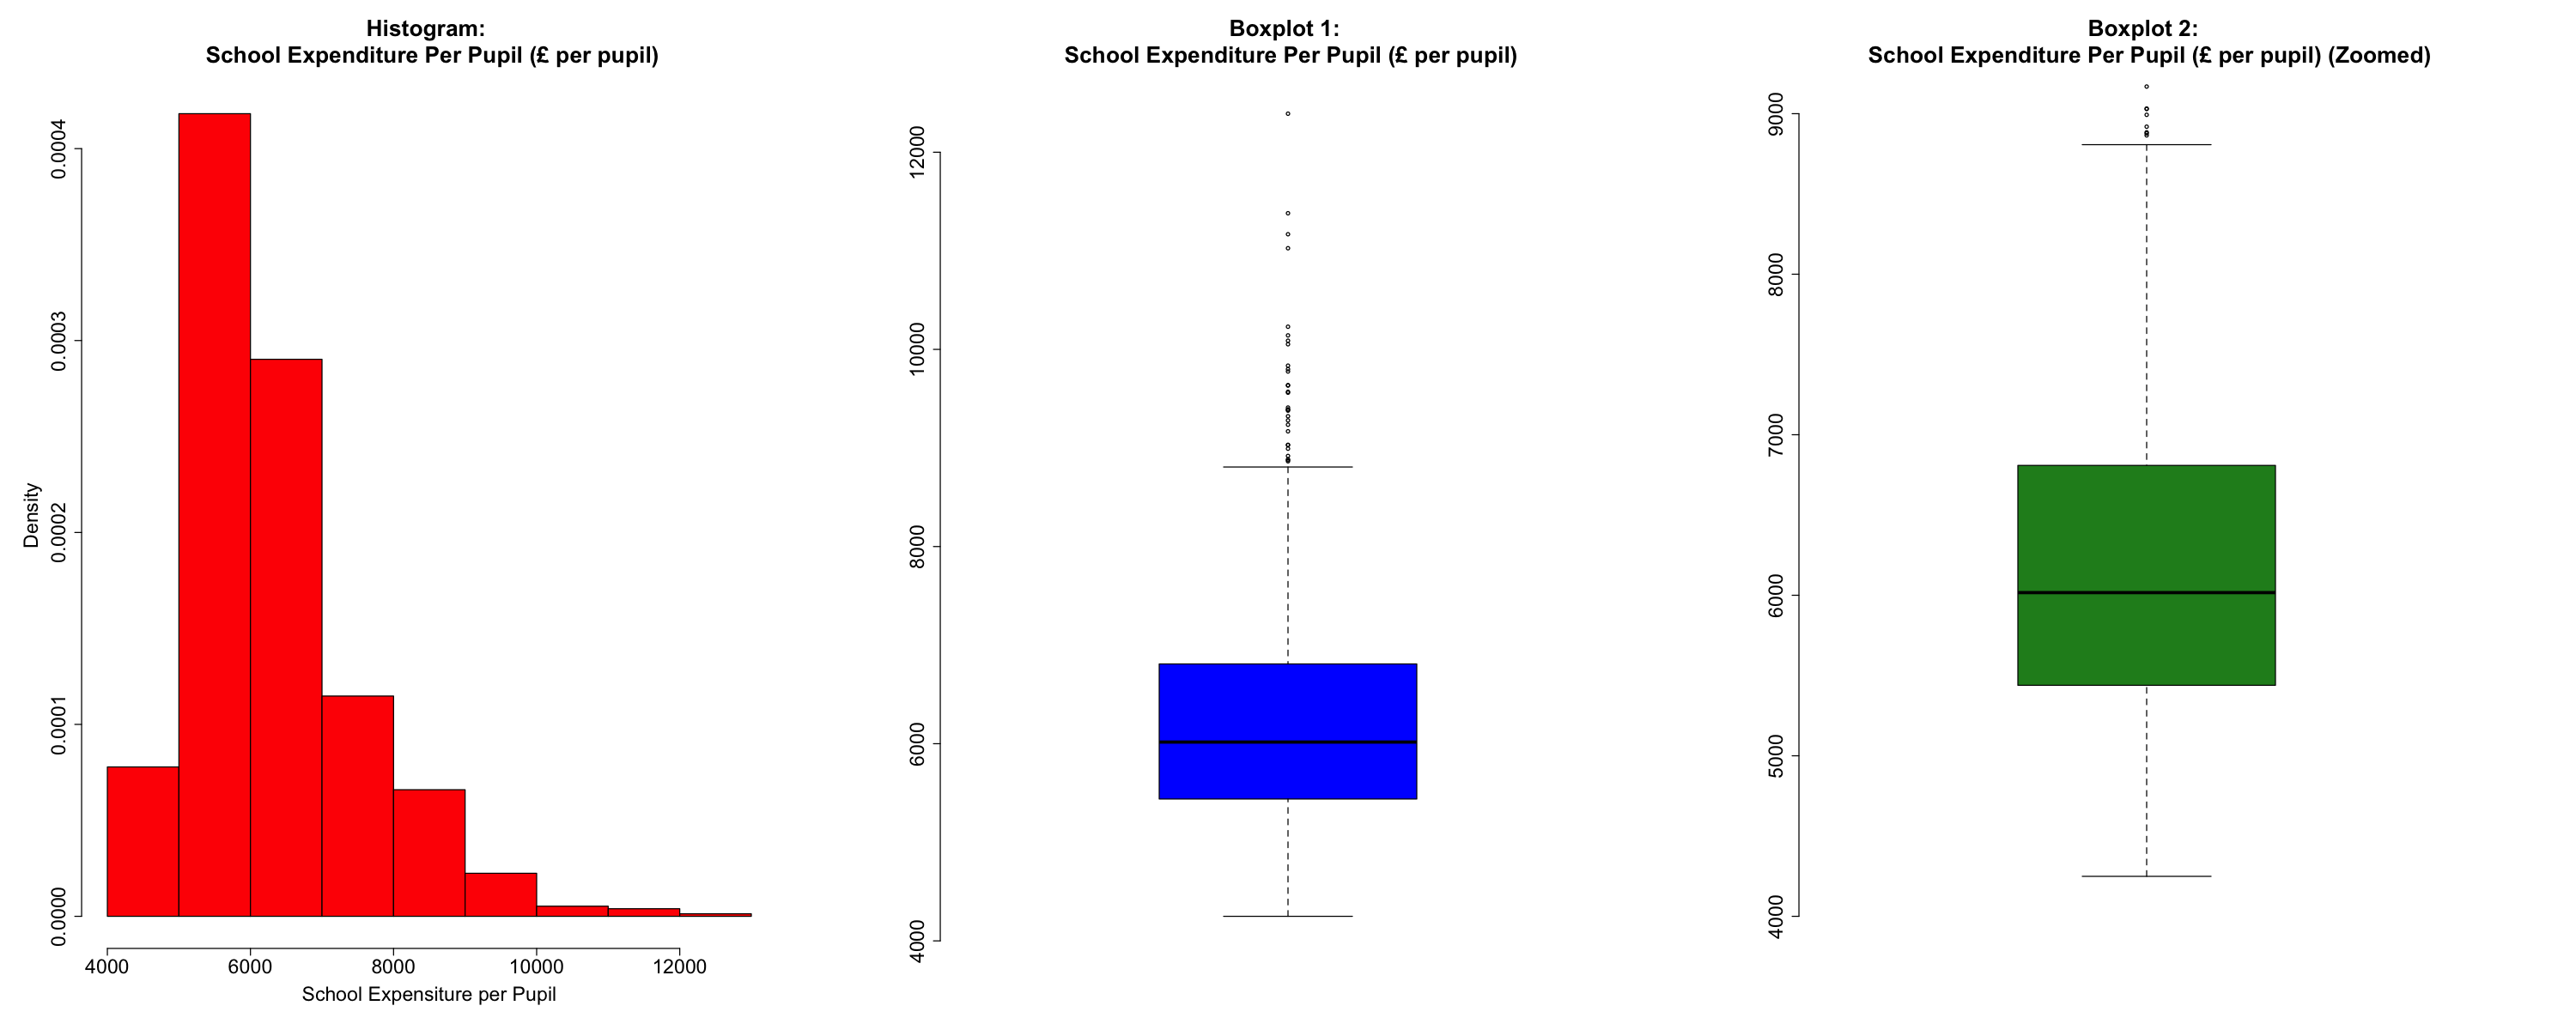

In [28]:
# Boxplot and histogram of EXPP:

# Set the plot size
options(repr.plot.width = 25, repr.plot.height = 10)

# Plotting parameters:
par(mfrow = c(1, 3) , bty="n" , mar=c(6,6,6,6) , cex.main=2.0 , cex.lab = 1.75 , cex.axis = 1.75  )


                 hist(EXPP,   
                               main = "Histogram: \n School Expenditure Per Pupil (£ per pupil)",
                                col = "red",
                               xlab = "School Expensiture per Pupil",
                               ylab = "Density",
                               freq = FALSE )


                boxplot(EXPP,                                                         
                               main = "Boxplot 1: \n School Expenditure Per Pupil (£ per pupil)",
                                col = "blue" )
                               


                boxplot(EXPP,                                                         
                               main = "Boxplot 2: \n School Expenditure Per Pupil (£ per pupil) (Zoomed)",
                                col = "forest green",
                                ylim = c(4000, 9000))
                               

Histogram: 
This graph shows the frequency of spending levels, where the right tail extending toward £12,000 represents the extreme outliers of London boroughs that require higher funding for inner London salaries and social deprivation.

Boxplot 1:
This boxplot displays the total distribution of school spending, where the whiskers and individual points above the top line represent the extreme outliers. It identifies a small group of schools spending between £8,000 and £12,000 per pupil, which is significantly higher than the rest of the country. These points statistically confirm that the right skew seen in the histograms isn't just a trend, but a set of exceptional cases (primarily London boroughs) that operate under unique financial pressures like inner London pay scales.

Boxplot 2:
This plot focuses on the "interquartile range" (the green box), which contains the middle 50% of all data points. By removing the visual distraction of the extreme outliers, we see that the median spending sits at approximately £6,000, with most schools tightly packed within a £1,300 range. This highlights the typical" experience for most English schools. It showcases that while the London outliers exist, they do not represent the standard funding reality for the majority of the country.

### Statistical Pivot Table and Histograms

In this section, the pivot table that will be created includes statistics of percentiles, 80/20 ratios, and average income differences between UK regions. A large pivot table will be created that will compare the regions in addition to the overall data as a nation. 

In [29]:
# Pivot table
# School Expenditure Differences Per Pupil between and within UK regions
# Compare the 80/20 ratio for household income within each region with the average income differences between UK regions


pivot_table_EXPP_1  =  data_frame |> 

                  group_by(   REGION   ) |> 

                 summarise(                         count = n(),                      
                                            average.EXPP = mean(EXPP)  )   |>    
 
                    mutate(          
                                   relative.average.EXPP = ( average.EXPP / mean(data_frame$EXPP) )*100,
                              diff.relative.average.EXPP = relative.average.EXPP - 100  )

In [30]:
pivot_table_sorted_EXPP_1 = pivot_table_EXPP_1  |>  arrange( desc( pivot_table_EXPP_1$diff.relative.average.EXPP ) )

In [31]:
pivot_table_sorted_EXPP_1

REGION,count,average.EXPP,relative.average.EXPP,diff.relative.average.EXPP
<chr>,<int>,<dbl>,<dbl>,<dbl>
07_London,141,7433.801,118.23285,18.2328481
01_North_East,39,6666.103,106.02278,6.0227800
05_West_Midlands,69,6249.725,99.40039,-0.5996122
02_North_West,183,6057.858,96.34879,-3.6512067
04_East_Midlands,34,6047.029,96.17657,-3.8234317
06_East_of_England,34,5940.294,94.47897,-5.5210312
03_Yorkshire_Humberside,69,5922.014,94.18824,-5.8117643
09_South_West,49,5891.469,93.70242,-6.2975769
08_South_East,140,5807.393,92.36521,-7.6347942


In [32]:
# We need to compute the distribution statistics for each region in the UK:
# So we construct a pivot table by REGION

pivot_table_quantile_EXPP  =  data_frame |> 

                 group_by( REGION ) |> 

                 summarise(                         count = n(),                      
                                            average.EXPP = mean(EXPP), 
 
                                        Bottom.20.percent = quantile(EXPP, probs = 0.20, names = FALSE),
                                        Bottom.25.percent = quantile(EXPP, probs = 0.25, names = FALSE),
                                                   Median = quantile(EXPP, probs = 0.50, names = FALSE),
                                        Bottom.75.percent = quantile(EXPP, probs = 0.75, names = FALSE),          
                                        Bottom.80.percent = quantile(EXPP, probs = 0.80, names = FALSE), 
                                        Bottom.99.percent = quantile(EXPP, probs = 0.99, names = FALSE),
                                     Inter.Quartile.Range = quantile(EXPP, probs = 0.75, names = FALSE) - quantile(EXPP, probs = 0.25, names = FALSE),
                                              Ratio.80.20 = quantile(EXPP, probs = 0.80, names = FALSE) / quantile(EXPP, probs = 0.20, names = FALSE) 
                            )   |>    
 
                    mutate(          
                                   relative.average.EXPP = ( average.EXPP / mean(data_frame$EXPP) )*100,
                              diff.relative.average.EXPP = relative.average.EXPP - 100  )

In [33]:
pivot_table_sorted_quantile_EXPP = pivot_table_quantile_EXPP  |>  arrange( desc( pivot_table_quantile_EXPP$diff.relative.average.EXPP ) )

In [34]:
pivot_table_sorted_quantile_EXPP

REGION,count,average.EXPP,Bottom.20.percent,Bottom.25.percent,Median,Bottom.75.percent,Bottom.80.percent,Bottom.99.percent,Inter.Quartile.Range,Ratio.80.20,relative.average.EXPP,diff.relative.average.EXPP
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
07_London,141,7433.801,6195.0,6409.00,7324.0,8387.00,8622.0,10757.60,1978.00,1.391768,118.23285,18.2328481
01_North_East,39,6666.103,5696.0,5890.00,6433.0,6908.00,7189.4,10723.52,1018.00,1.262184,106.02278,6.0227800
05_West_Midlands,69,6249.725,5290.6,5411.00,5999.0,6833.00,7016.2,10824.96,1422.00,1.326163,99.40039,-0.5996122
02_North_West,183,6057.858,5280.4,5392.50,5857.0,6548.00,6715.4,9000.12,1155.50,1.271760,96.34879,-3.6512067
04_East_Midlands,34,6047.029,5295.4,5544.00,5985.0,6579.75,6641.4,8784.43,1035.75,1.254183,96.17657,-3.8234317
06_East_of_England,34,5940.294,5419.2,5439.25,5732.0,6172.25,6357.8,8459.79,733.00,1.173199,94.47897,-5.5210312
03_Yorkshire_Humberside,69,5922.014,5334.6,5374.00,5677.0,6195.00,6366.2,8641.48,821.00,1.193379,94.18824,-5.8117643
09_South_West,49,5891.469,5271.4,5343.00,5839.0,6236.00,6270.6,8839.24,893.00,1.189551,93.70242,-6.2975769
08_South_East,140,5807.393,5065.4,5116.00,5650.5,6275.75,6357.2,8678.27,1159.75,1.255024,92.36521,-7.6347942


In [35]:
# Add the last row with the grand totals for the entire UK:

pivot_table_grand_totals  =  data_frame |> 

                              summarise(            count = n(),                      
                                            average.EXPP = mean(EXPP), 
 
                                        Bottom.20.percent = quantile(EXPP, probs = 0.20, names = FALSE),
                                        Bottom.25.percent = quantile(EXPP, probs = 0.25, names = FALSE),
                                                   Median = quantile(EXPP, probs = 0.50, names = FALSE),
                                        Bottom.75.percent = quantile(EXPP, probs = 0.75, names = FALSE),          
                                        Bottom.80.percent = quantile(EXPP, probs = 0.80, names = FALSE), 
                                        Bottom.99.percent = quantile(EXPP, probs = 0.99, names = FALSE),
                                     Inter.Quartile.Range = quantile(EXPP, probs = 0.75, names = FALSE) - quantile(EXPP, probs = 0.25, names = FALSE),
                                              Ratio.80.20 = quantile(EXPP, probs = 0.80, names = FALSE) / quantile(EXPP, probs = 0.20, names = FALSE) 
                            )   |>    
 
                    mutate(          
                                   relative.average.EXPP = ( average.EXPP / mean(data_frame$EXPP) )*100,
                              diff.relative.average.EXPP = relative.average.EXPP - 100  )


# Combine the "pivot table by region" with the "pivot table with the grand totals for the entire UK":

pivot_table_grand_totals = cbind(REGION="Grand Total", pivot_table_grand_totals)     # Adds the label "Grand Total"

final_pivot_table = rbind( pivot_table_sorted_quantile_EXPP, pivot_table_grand_totals)             # Merges row-wise the "pivot_table_sorted" and "pivot_table_grand_totals"

In [36]:
final_pivot_table

REGION,count,average.EXPP,Bottom.20.percent,Bottom.25.percent,Median,Bottom.75.percent,Bottom.80.percent,Bottom.99.percent,Inter.Quartile.Range,Ratio.80.20,relative.average.EXPP,diff.relative.average.EXPP
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
07_London,141,7433.801,6195.0,6409.00,7324.0,8387.00,8622.0,10757.60,1978.00,1.391768,118.23285,18.2328481
01_North_East,39,6666.103,5696.0,5890.00,6433.0,6908.00,7189.4,10723.52,1018.00,1.262184,106.02278,6.0227800
05_West_Midlands,69,6249.725,5290.6,5411.00,5999.0,6833.00,7016.2,10824.96,1422.00,1.326163,99.40039,-0.5996122
02_North_West,183,6057.858,5280.4,5392.50,5857.0,6548.00,6715.4,9000.12,1155.50,1.271760,96.34879,-3.6512067
04_East_Midlands,34,6047.029,5295.4,5544.00,5985.0,6579.75,6641.4,8784.43,1035.75,1.254183,96.17657,-3.8234317
06_East_of_England,34,5940.294,5419.2,5439.25,5732.0,6172.25,6357.8,8459.79,733.00,1.173199,94.47897,-5.5210312
03_Yorkshire_Humberside,69,5922.014,5334.6,5374.00,5677.0,6195.00,6366.2,8641.48,821.00,1.193379,94.18824,-5.8117643
09_South_West,49,5891.469,5271.4,5343.00,5839.0,6236.00,6270.6,8839.24,893.00,1.189551,93.70242,-6.2975769
08_South_East,140,5807.393,5065.4,5116.00,5650.5,6275.75,6357.2,8678.27,1159.75,1.255024,92.36521,-7.6347942


The pivot table reveals clear regional inequalities in school expenditure per pupil (EXPP) across England. London stands out with significantly higher funding well above the national mean, indicating a strong resource advantage. While the Northeast also exceeds the average, most regions, including the South East and South West, fall below it, suggesting a London versus the rest divide. Differences in interquartile ranges show that London also experiences greater internal variation. These disparities imply unequal access to educational resources, which may contribute to differences in student outcomes and reinforce broader regional inequalities.

## Question 2: Evolution Over Time

This section aims to answer how the recent evolution of total gross expenditure by secondary schools across England has developed over time. It will include nominal and real growth rates and inflation rates to depict and summarize the evolution of schools' expenditure and compare it to the funding provided throughout the UK. It uses a different dataset to create time series charts to visualize the change over time and understand relations between expenditure and funding. 

### Data Set for Question 2

In [37]:
# Load the data from Excel:
AppQE_TS_project_01 = read_excel("AppQE_TS_project_01.xlsx", sheet="Data_for_R")
attach(AppQE_TS_project_01)

In [38]:
AppQE_TS_project_01

Year,Total Gross Expenditure,Total Funding,GDP deflator
<chr>,<dbl>,<dbl>,<dbl>
1999_00,9021.387,8394.535,71.25073
2000_01,10144.322,9439.442,72.72745
2001_02,11267.257,10484.350,73.62080
2002_03,11329.022,10541.824,75.34355
2003_04,12556.787,11924.976,76.99260
2004_05,13476.384,12752.004,79.13555
2005_06,14474.677,13555.581,81.20148
2006_07,15206.804,14295.029,83.74465
2007_08,16008.636,15148.427,85.82377


### First Time Series Plot: Nominal and Real Trends ###

The initial time series analysis evaluates the trajectory of secondary school expenditure and funding from 1999 to 2016. By comparing nominal figures with inflation adjusted real values, the plot illustrates the evolving purchasing power and fiscal constraints within the United Kingdom education system.

In [39]:
# Change the names of the variables
# Then tell R they are in fact time series (ts) objects
# Create a data frame using the new variables

                    Year = ts(1999:2016)
Total_Gross_Expenditures = ts(AppQE_TS_project_01$`Total Gross Expenditure`,  start=1999,  frequency=1)
           Total_Funding = ts(AppQE_TS_project_01$`Total Funding`,            start=1999,  frequency=1)
            GDP_deflator = ts(AppQE_TS_project_01$`GDP deflator`,             start=1999,  frequency=1)

In [40]:
# Now deflate the nominal series using the GDP_deflator series:
# The price index for the base year should be 1, not 100, so we divide the price deflator by 100
# We are in fact converting the base year from 2016=100 to 2016=1

Real_Total_Gross_Expenditures = Total_Gross_Expenditures / (GDP_deflator/100)
           Real_Total_Funding = Total_Funding            / (GDP_deflator/100)

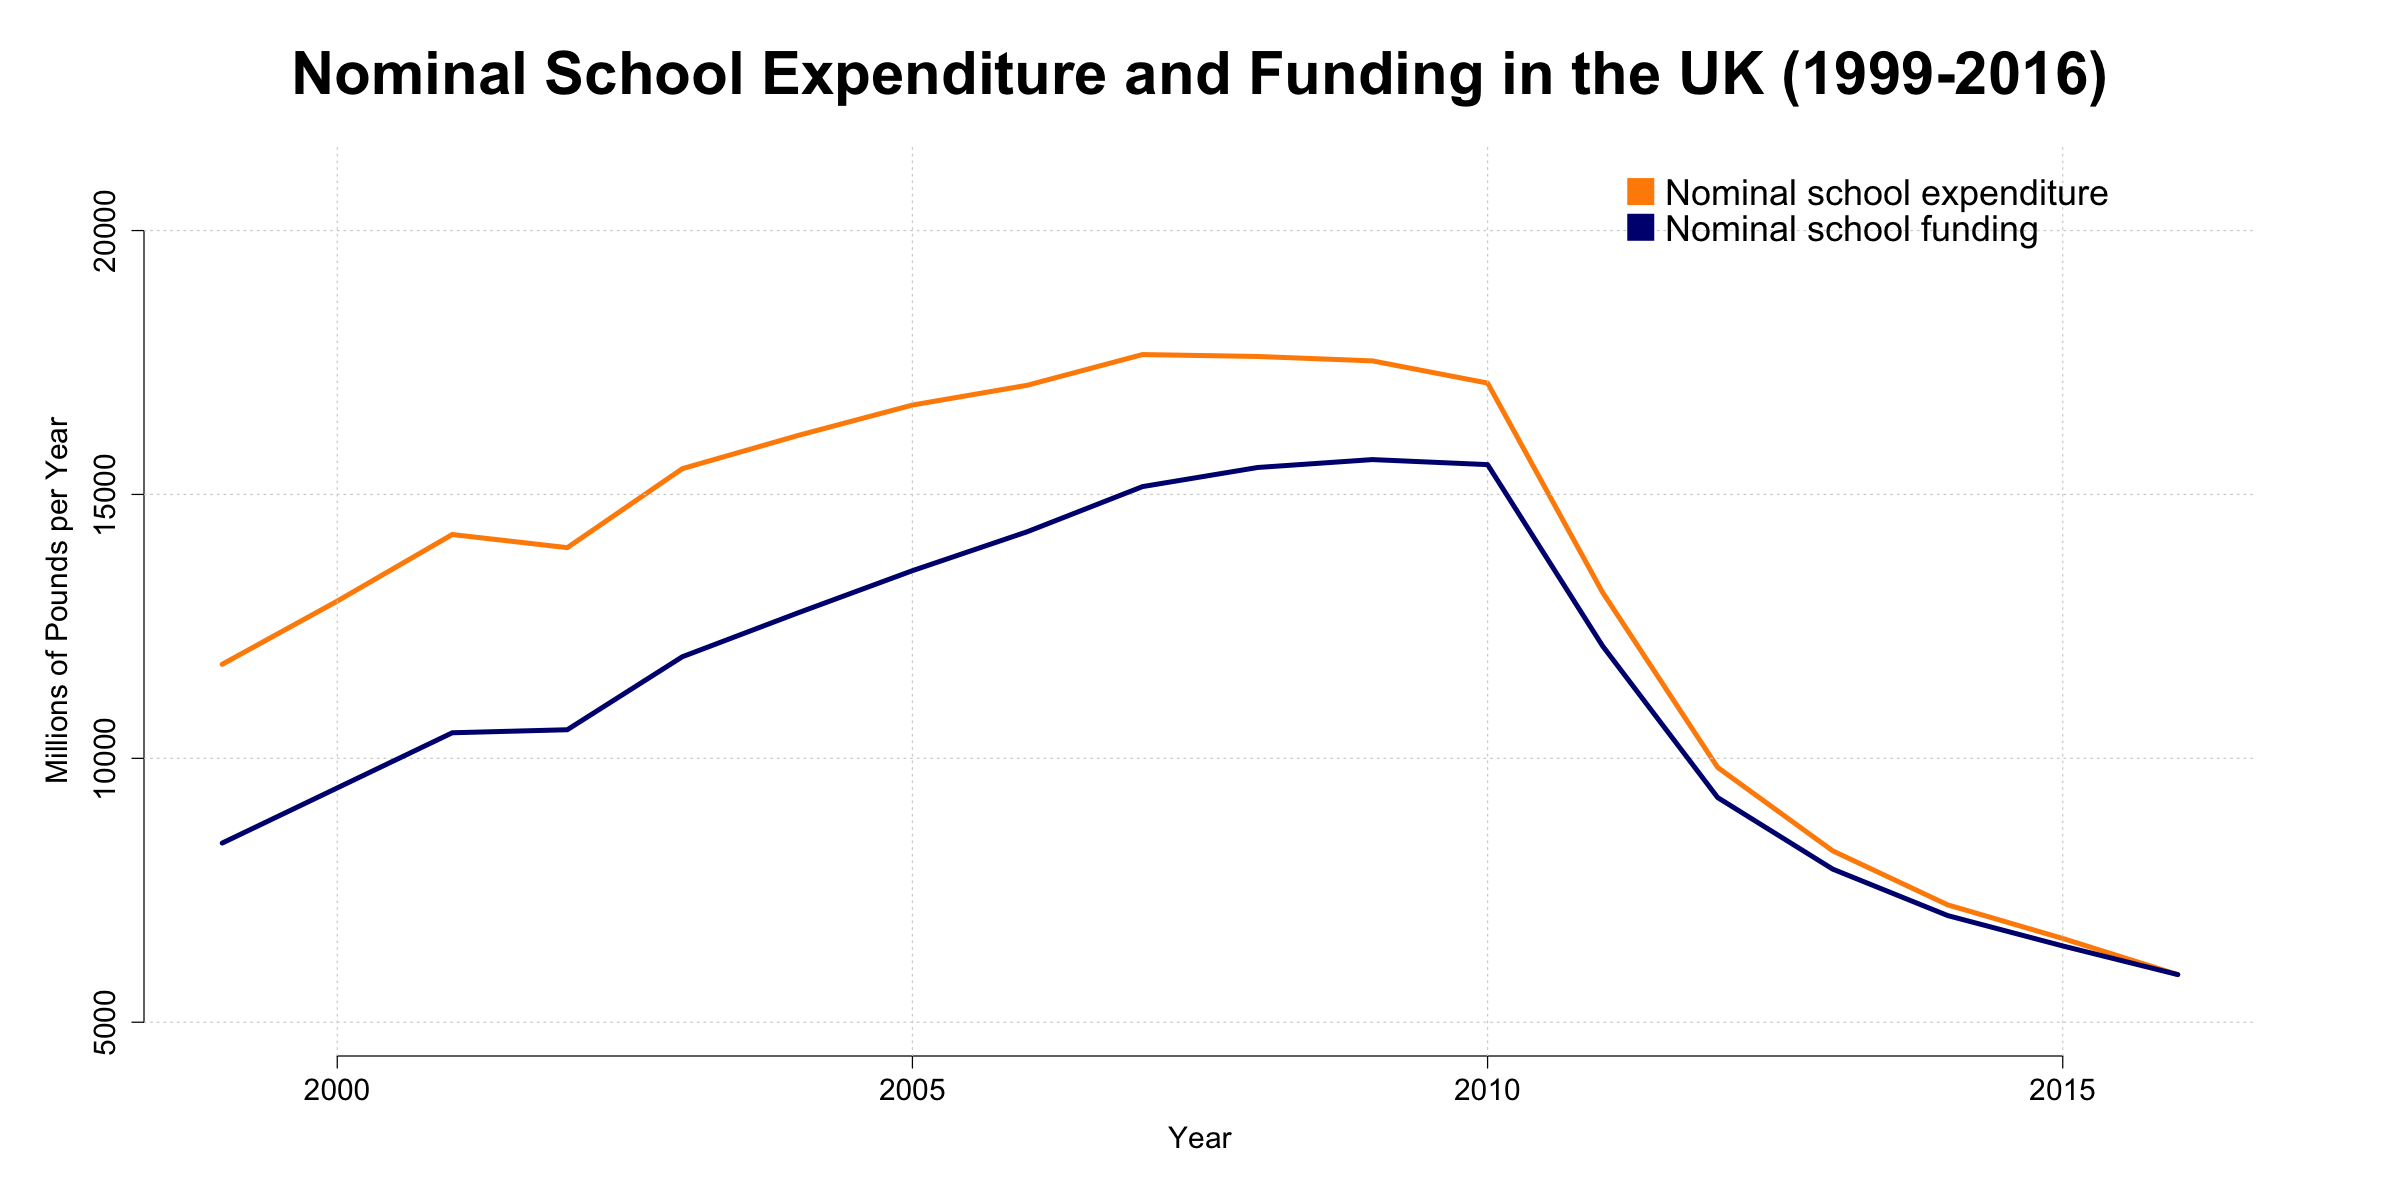

In [41]:
options(repr.plot.width = 20, repr.plot.height = 10)

par(mfrow = c(1,1) , bty="n" , mar=c(6,6,6,6) , cex.main=2.0 , cex.lab = 1.5 , cex.axis = 1.5 )


    plot(Real_Total_Funding, 
                                        col = "darkorange",   
                                        lwd = 4, 
                                       xlab = "Year", 
                                       ylab = "Millions of Pounds per Year", 
                                       main = "Nominal School Expenditure and Funding in the UK (1999-2016)" , cex.main=3 ,
                                       ylim = c(5000 , 21000) )

        grid()

        lines(Total_Funding,    
                                        col = "navyblue", 
                                        lwd = 4)

        
        legend( "bottomleft",                                                                    # place the legend at the bottom of the plot
               
                legend = c("Nominal school expenditure","Nominal school funding" ),                    # legend labels
                  col  = c("darkorange","navyblue"),                                             # legend colors
                   pch = 15,                                                                     # type of legend symbol
                   cex = 1.8,                                                                    # legend font size
                pt.cex = 3.0,                                                                    # increase symbol size
                    bg = "white",                                                                # legend background color
                   bty = "n",                                                                    # type of legend box
                 horiz = FALSE,                                                                  # display the legend horizontally
                 inset = c(0.65, 0.85),                                                          # move the legend slightly outside the plot
             x.intersp = 0.20,                                                                   # reduce the spacing between color fill and text labels
             y.intersp = 0.5,
            text.width = 4.0)                                                                    # adjust the text width to compress the legend  

The time series highlights a hard budget constraint as nominal expenditure tracks funding almost perfectly from 1999 to 2016. This symmetry confirms that secondary schools in the United Kingdom operate without significant financial reserves and spend precisely what they are allocated. The data reveal a sharp contraction after 2010, marking a period of fiscal austerity. Regarding regional inequality, this national reduction in liquidity is critical because, as total capital in the system decreases, regions with lower funding baselines face immediate operational pressure, as they lack the additional resource margins found in higher expenditure areas, such as London.

Next, we are using the same data from the time series above. However, by dividing total funding/expenditure by (GDP_deflator / 100), we view the time series using real values. 

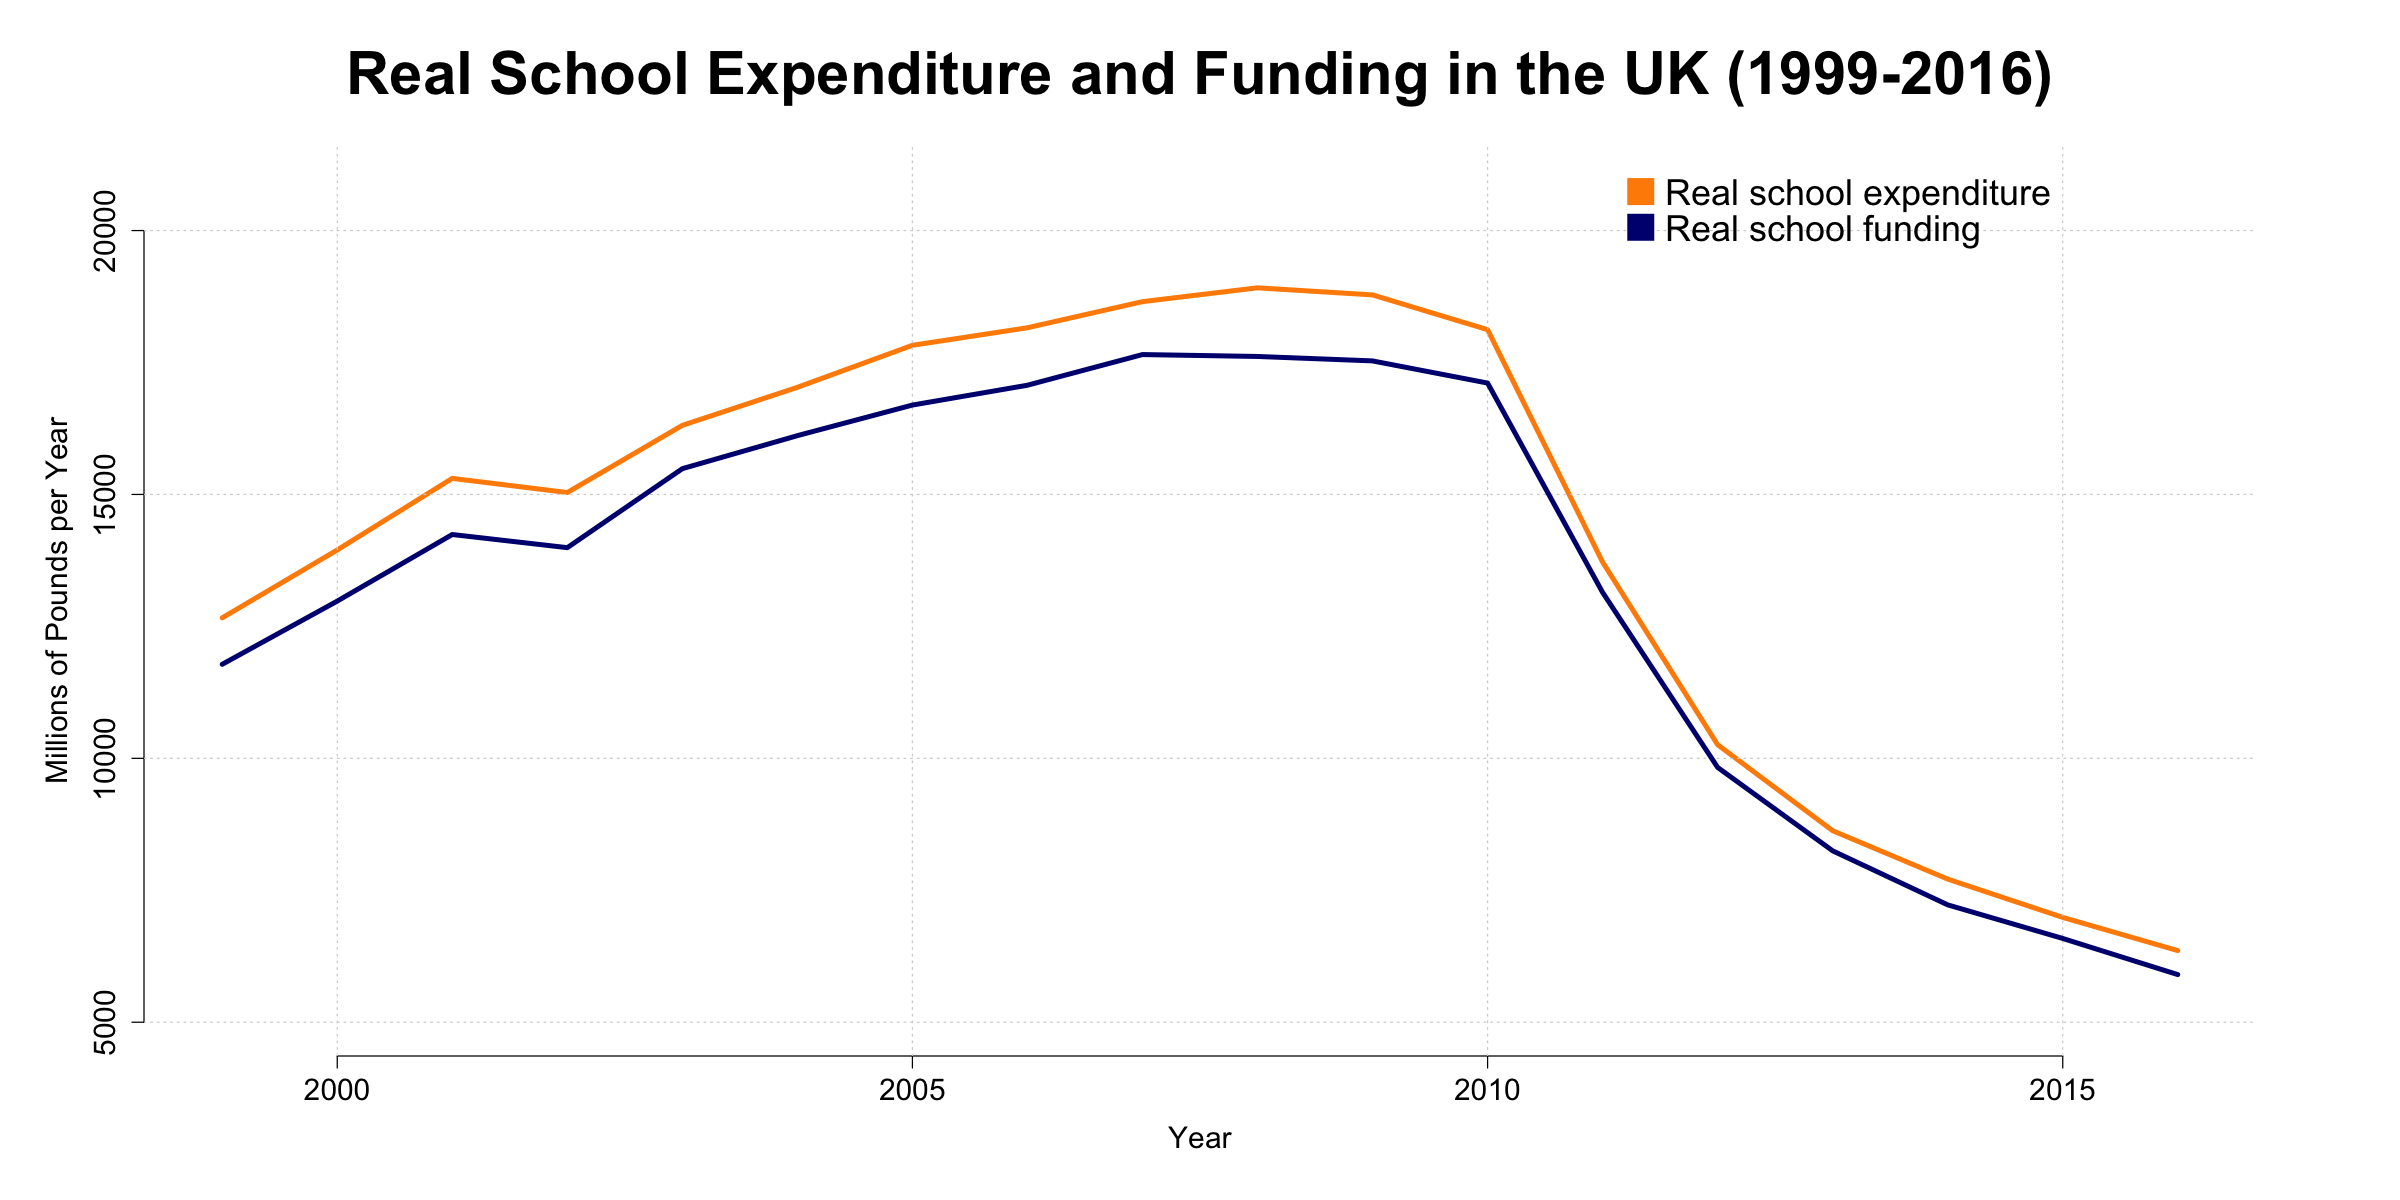

In [42]:
# Set the plot size
options(repr.plot.width = 20, repr.plot.height = 10)

# Plotting parameters:
par(mfrow = c(1,1) , bty="n" , mar=c(6,6,6,6) , cex.main=2.0 , cex.lab = 1.5 , cex.axis = 1.5 )


    plot(Real_Total_Gross_Expenditures, 
                                        col = "darkorange",   
                                        lwd = 4, 
                                       xlab = "Year", 
                                       ylab = "Millions of Pounds per Year", 
                                       main = "Real School Expenditure and Funding in the UK (1999-2016)" , cex.main=3 ,
                                       ylim = c(5000 , 21000) )

        grid()

        lines(Real_Total_Funding,    
                                        col = "navyblue", 
                                        lwd = 4)

        
        legend( "bottomleft",                                                                    # place the legend at the bottom of the plot
               
                legend = c("Real school expenditure","Real school funding" ),                    # legend labels
                  col  = c("darkorange","navyblue"),                                             # legend colors
                   pch = 15,                                                                     # type of legend symbol
                   cex = 1.8,                                                                    # legend font size
                pt.cex = 3.0,                                                                    # increase symbol size
                    bg = "white",                                                                # legend background color
                   bty = "n",                                                                    # type of legend box
                 horiz = FALSE,                                                                  # display the legend horizontally
                 inset = c(0.65, 0.85),                                                          # move the legend slightly outside the plot
             x.intersp = 0.20,                                                                   # reduce the spacing between color fill and text labels
             y.intersp = 0.5,
            text.width = 4.0)                                                                    # adjust the text width to compress the legend  

The real time series illustrates the entire trajectory of school finances after adjusting for inflation using the GDP deflator. This transformation evaluates the actual purchasing power of the education sector. The results show that real school expenditure and funding track each other closely, which reinforces the existence of a persistent hard budget constraint at the national level. As the fall in 2010 occurs, both real and nominal values show unanimous decreases, signaling overall less available money in the economy. This suggests that the post-2010 austerity measures were sufficiently drastic to offset any potential gains from lower inflationary periods, locking the education system into a prolonged phase of resource depletion.

### Second Time Series Plot: Nominal and Real Growth Rates, Inflation Rates ###

The following comparison tracks the annual percentage fluctuations in school funding relative to macroeconomic price indices. Plotting nominal and real growth rates alongside inflation identifies specific periods where rising costs eroded the functional value of the education budget.

In [43]:
# Calculate the average annual growth rate for Real Total Gross Expenditures 
# from 1999 to 2008 using log differences.
Real_Total_Gross_Expenditures |> window( start=1999 , end=2008 ) |>  log() |> diff() |> mean()

# Calculate the average annual growth rate for Real Total Funding 
# during the austerity period (2008 to 2016) using log differences.
Real_Total_Funding            |> window( start=2008 , end=2016 ) |>  log() |> diff() |> mean()

[1] 0.0446008

[1] -0.136668

In [44]:
# Decompose the series: nominal = real + inflation

inflation.rate = diff(log(GDP_deflator))  # rate of inflation

In [45]:
# Compute the real and nominal growth rates of expenditures and funding for the entire period:

growth.rate.of.real.School.Expenditures    = diff(log( Real_Total_Gross_Expenditures )) 
growth.rate.of.nominal.School.Expenditures = diff(log( Total_Gross_Expenditures      )) 

growth.rate.of.real.School.Funding         = diff(log( Real_Total_Funding            )) 
growth.rate.of.nominal.School.Funding      = diff(log( Total_Funding                 )) 

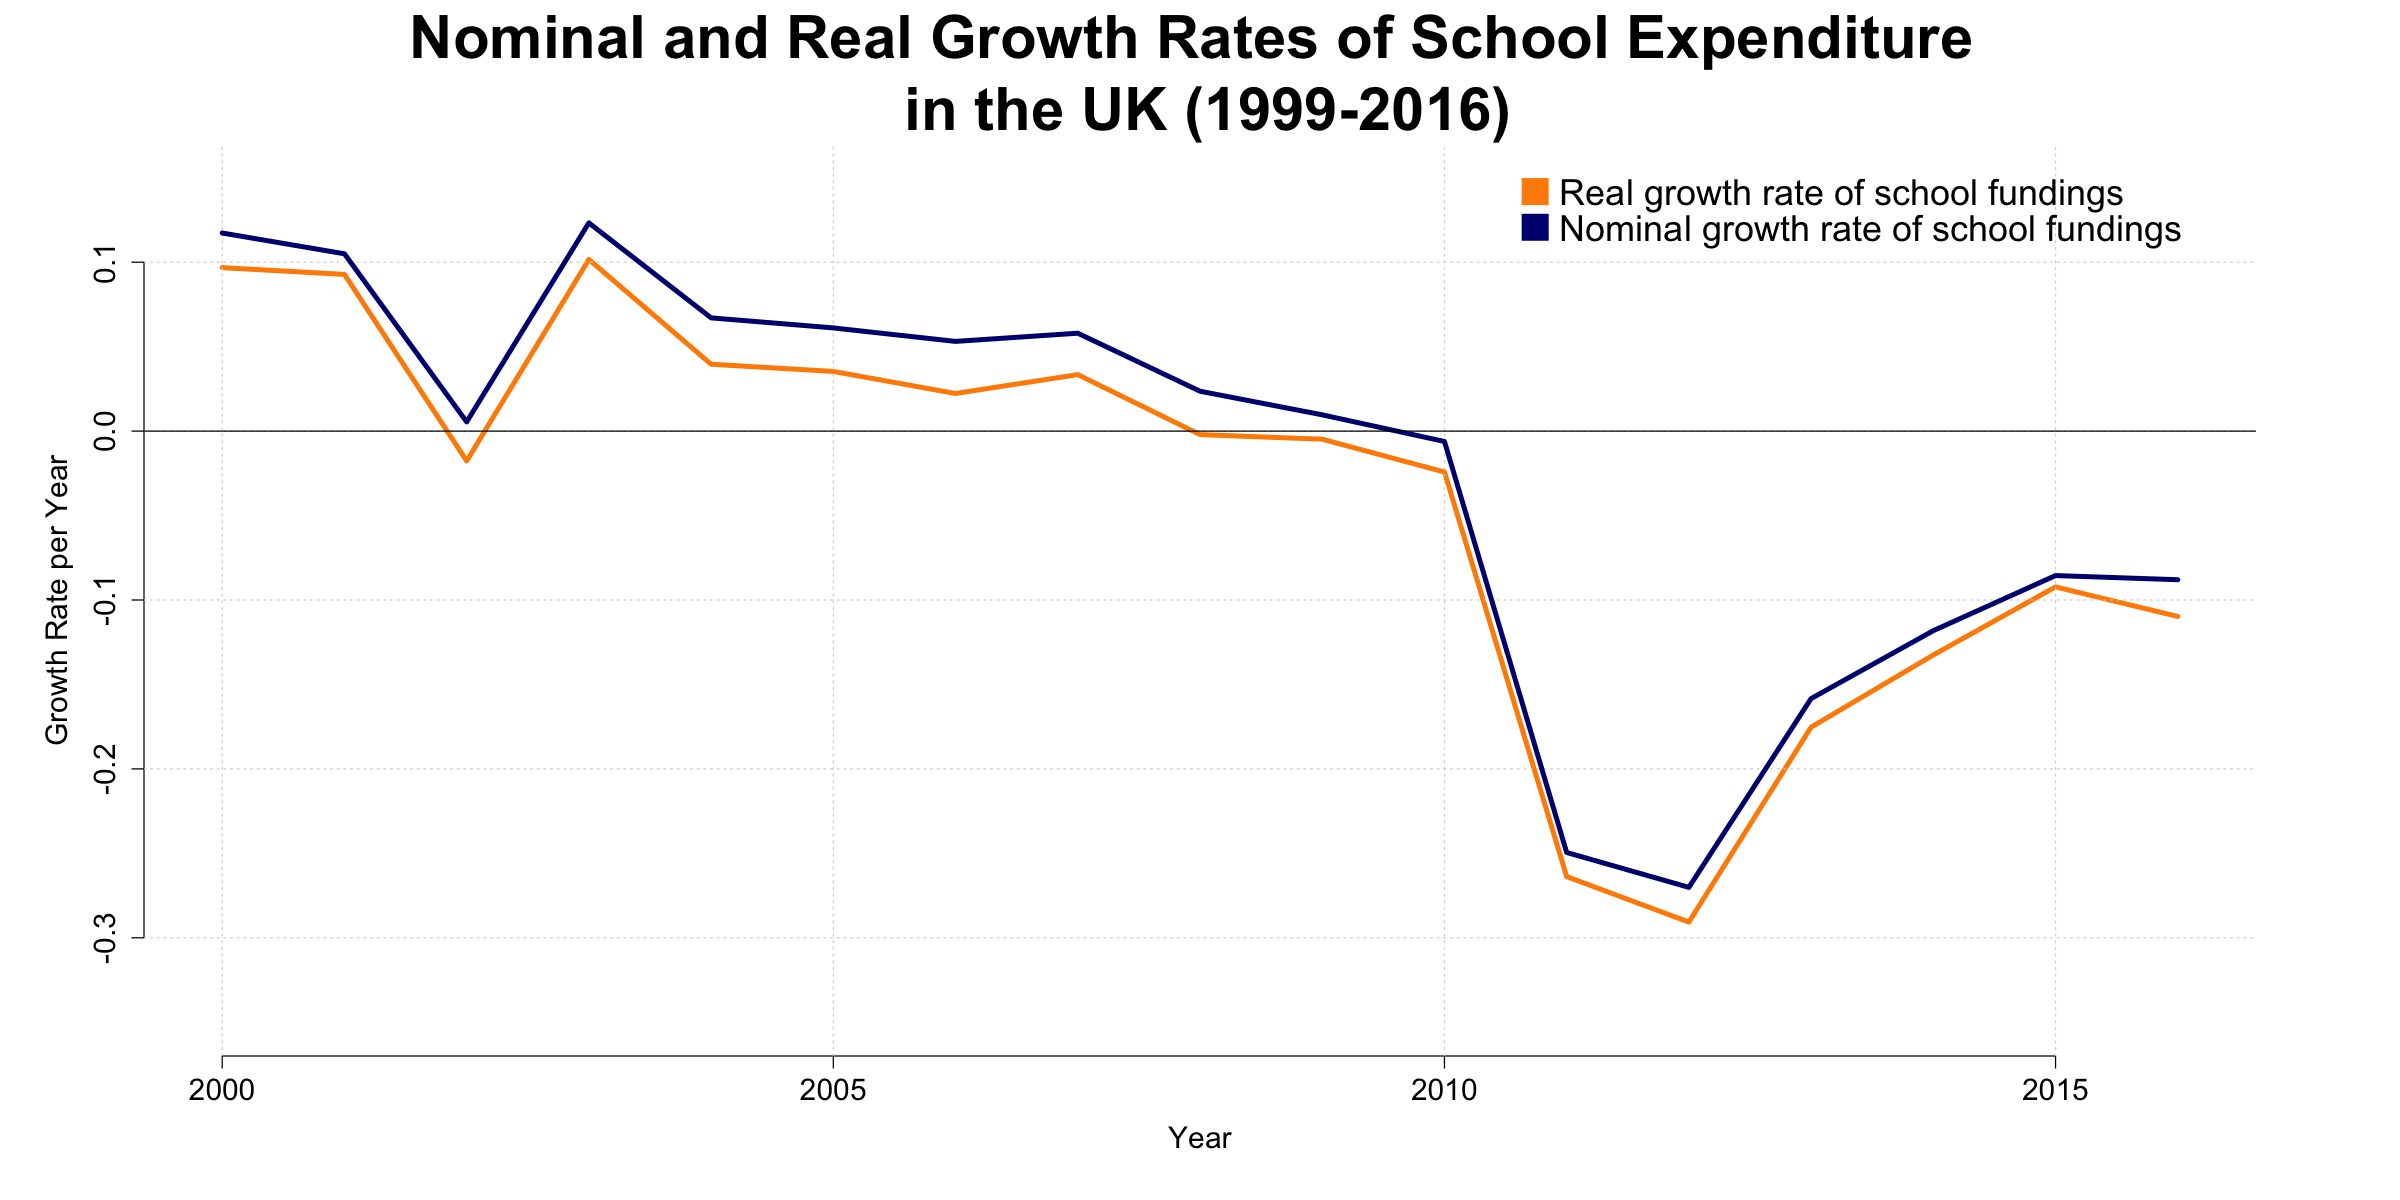

In [46]:
# Plot the real and nominal expenditures together, both in terms of growth rates:

options(repr.plot.width = 20, repr.plot.height = 10)

par(mfrow = c(1,1) , bty="n" , mar=c(6,6,6,6) , cex.main=2.0 , cex.lab = 1.5 , cex.axis = 1.5 )


    plot(growth.rate.of.real.School.Funding, 
                                        col = "darkorange",   
                                        lwd = 4, 
                                       xlab = "Year", 
                                       ylab = "Growth Rate per Year", 
                                       main = "Nominal and Real Growth Rates of School Expenditure \n in the UK (1999-2016)" , cex.main=3 ,
                                       ylim = c(-0.35 , .15))

        grid()

        lines(growth.rate.of.nominal.School.Funding,    
                                        col = "navyblue", 
                                        lwd = 4)
                        
        abline(h=0)


        legend( "bottomleft",                                                                    # place the legend at the bottom of the plot
               
                legend = c("Real growth rate of school fundings",
                           "Nominal growth rate of school fundings" ),                       # legend labels
                  col  = c("darkorange","navyblue"),                                             # legend colors
                   pch = 15,                                                                     # type of legend symbol
                   cex = 1.8,                                                                    # legend font size
                pt.cex = 3.0,                                                                    # increase symbol size
                    bg = "white",                                                                # legend background color
                   bty = "n",                                                                    # type of legend box
                 horiz = FALSE,                                                                  # display the legend horizontally
                 inset = c(0.60, 0.85),                                                          # move the legend slightly outside the plot
             x.intersp = 0.20,                                                                   # reduce the spacing between color fill and text labels
             y.intersp = 0.5,
            text.width = 4.0)                                                                    # adjust the text width to compress the legend  

The growth rate analysis demonstrates that nominal and real school funding follow an almost identical trajectory. This synchronized shape occurs because inflation remained relatively stable during the period, acting as a consistent downward shift rather than a volatile disruptor. While both metrics were positive in the early 2000s, they entered a sharp, parallel decline after 2010. The significance of this trend is that the fiscal contraction was so severe that low inflation pushed real growth deep into negative territory. This forced schools to manage a substantial loss in actual purchasing power as the rate of budget reduction outpaced the broader economy. By tracking so closely together, these indicators suggest that the primary driver of real-term financial distress was the aggressive reduction in nominal allocations rather than unpredictable shifts in the consumer price index.

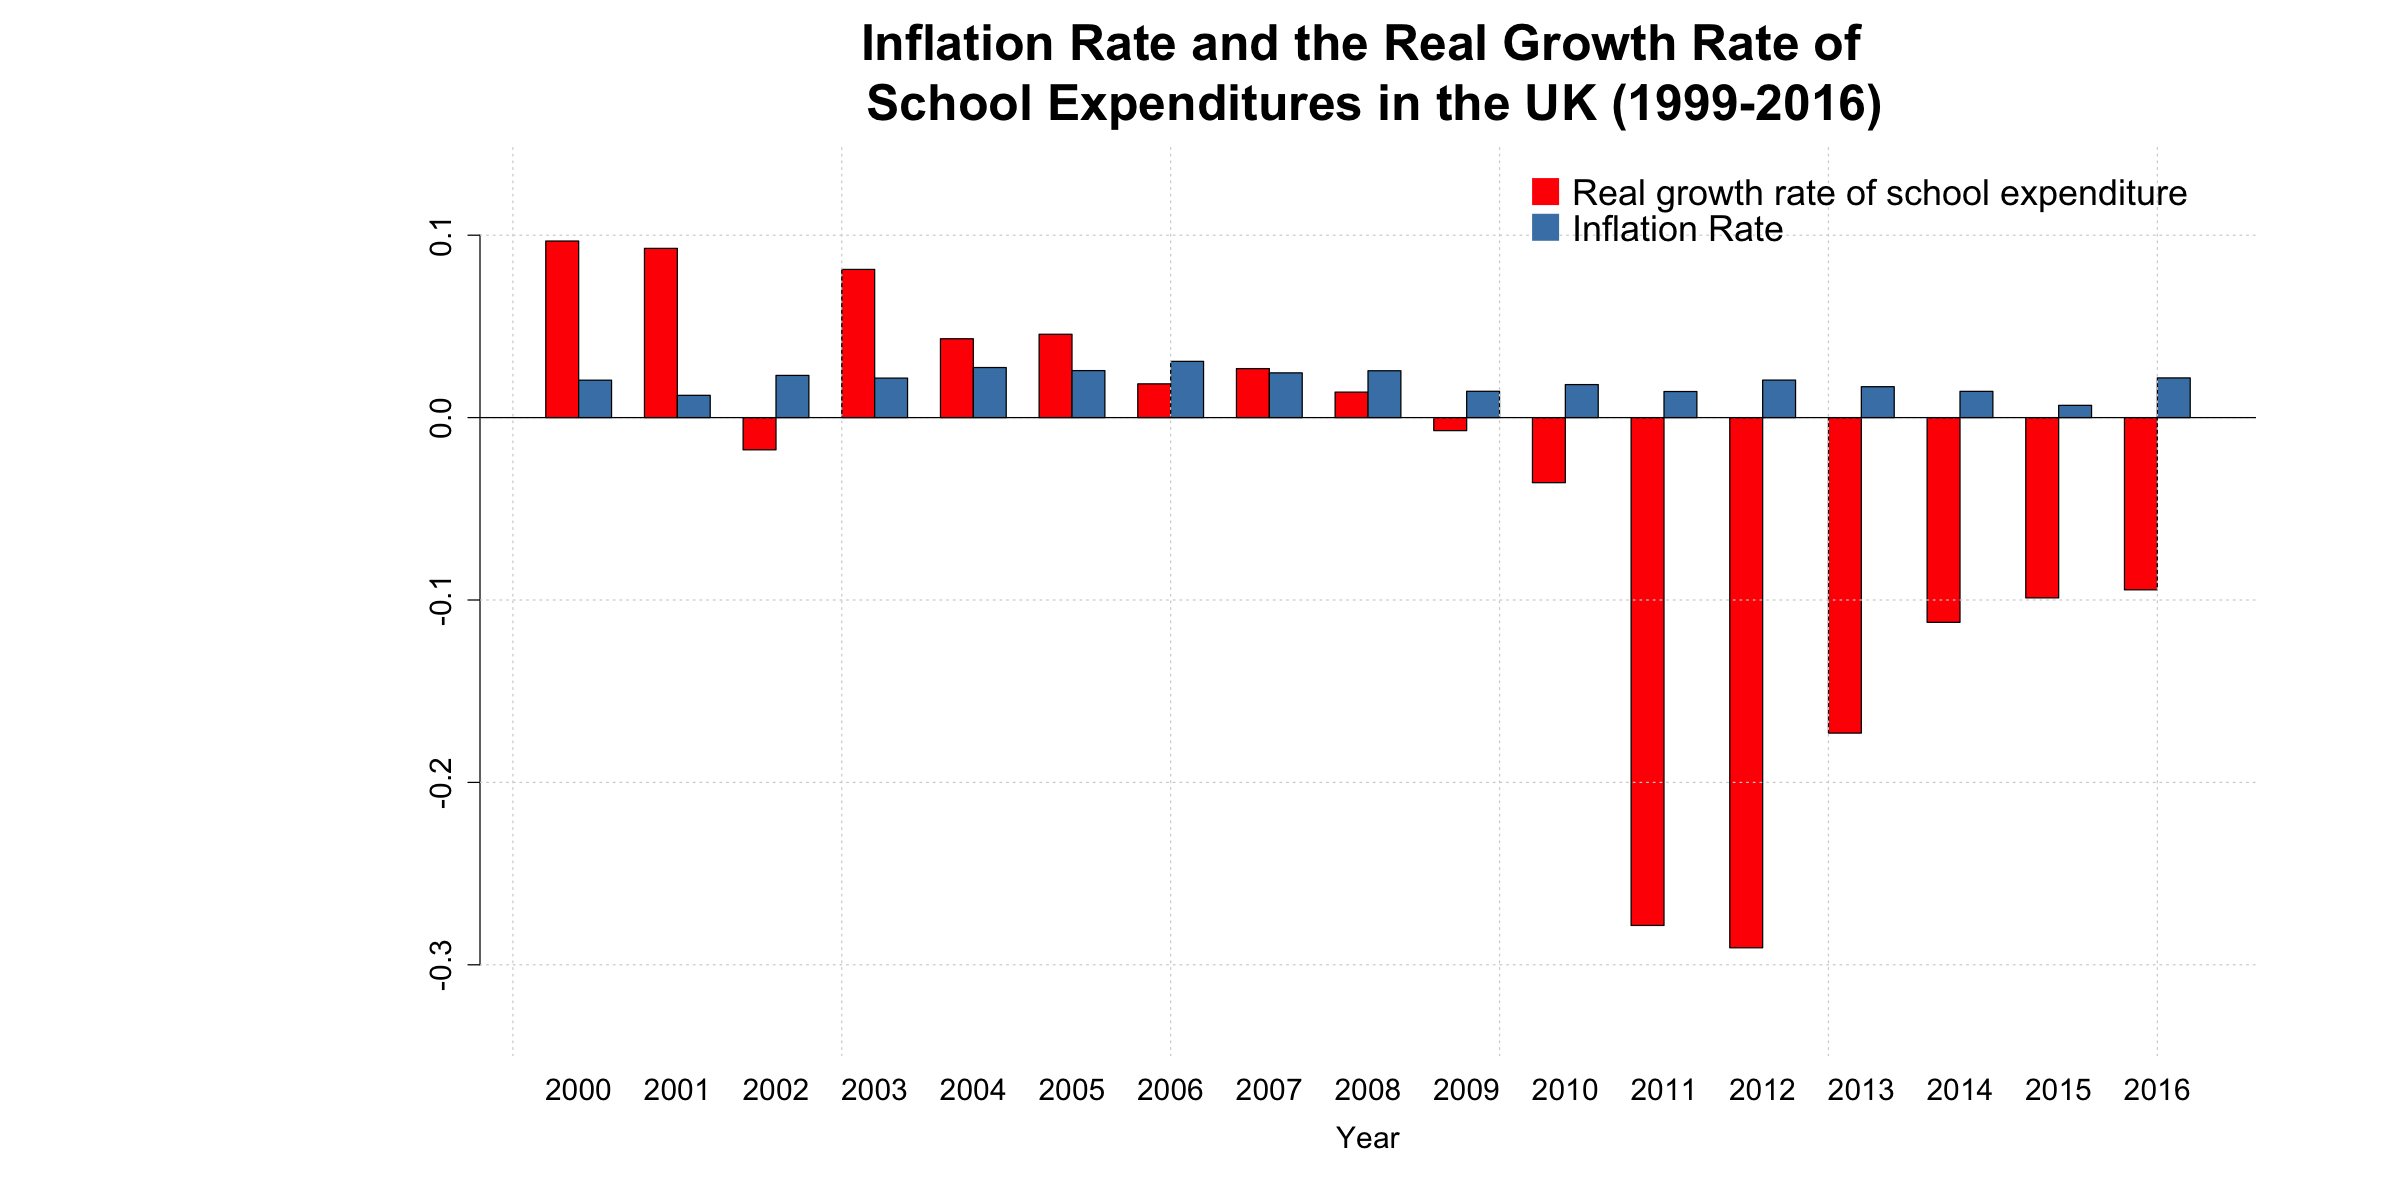

In [47]:
# Plot the growth rate of real expenditures together with the rate of inflation, using barplots:

barplot.data = rbind(growth.rate.of.real.School.Expenditures, inflation.rate)     # transposed data frame for the barplot() function: variables in rows, time in columns


options(repr.plot.width = 20, repr.plot.height = 10)

par(mfrow = c(1,1) , bty="n" , mar=c(6,20,6,6) , cex.main=2.0 , cex.lab = 1.5 , cex.axis = 1.5 )


        barplot(barplot.data, 
                                  ylim = c(-0.35 , 0.15),
                                  main = "Inflation Rate and the Real Growth Rate of \n School Expenditures in the UK (1999-2016)", cex.main=2.5,
                                beside = TRUE,
                                  xlab = "Year",
                             names.arg = Year[2:18],
                                   col = c( "red", "steelblue" )  )

        grid()
        abline(h=0)
        
        legend( "bottomleft",                                                                    # place the legend at the bottom of the plot
               
                legend = c("Real growth rate of school expenditure",  "Inflation Rate" ),       # legend labels
                  col  = c("red","steelblue"),                                             # legend colors
                   pch = 15,                                                                     # type of legend symbol
                   cex = 1.8,                                                                    # legend font size
                pt.cex = 3.0,                                                                    # increase symbol size
                    bg = "white",                                                                # legend background color
                   bty = "n",                                                                    # type of legend box
                 horiz = FALSE,                                                                  # display the legend horizontally
                 inset = c(0.45, 0.85),                                                          # move the legend slightly outside the plot
             x.intersp = 0.10,                                                                   # reduce the spacing between color fill and text labels
             y.intersp = 0.5,
            text.width = 4.0)                                                                    # adjust the text width to compress the legend  

The bar chart illustrates the relationship between the annual inflation rate and the real growth rate of school expenditure. From 2000 to 2008, the relationship was positive because budget increases consistently outpaced inflation, allowing schools to maintain a surplus in purchasing power. This trend reversed from 2009 onward as fiscal policy shifted. During this latter period, real growth bars fall significantly below the zero axis while inflation remains positive. This divergence indicates that rising prices compounded the impact of nominal budget cuts. The resulting negative real growth signifies a systemic reduction in the actual resources available to the education sector. Consequently, the widening gap between these variables highlights how macroeconomic cost pressures effectively accelerated the decline in school liquidity beyond the scale of the initial funding reductions.

## Question 3: What are the determinants of secondary school expenditure?

This multivariate regression analysis identifies the primary drivers of secondary school spending. By evaluating five distinct models, including standardized coefficients, the study isolates key variable impacts while utilizing interaction dummies and residual diagnostics to interpret regional funding disparities.

In [60]:
AppQE_project_sample = read_excel( "AppQE_project_sample - Full Sample (758 schools).xlsx"  ,  sheet = "data" )   
attach(AppQE_project_sample)

The following object is masked _by_ .GlobalEnv:

    REGION


The following objects are masked from Project_Sample_758 (pos = 3):

    ATT8SCR, DLONDON, DMIXED, EXP, EXPLRESP, EXPP, GENDER, INC, INCP, ISPOST16, ISPRIMARY, ISSECONDARY, LANAME, LAPAY, PENGFL, PFSM, PSEN, PUP, PUPKS4, RATPUPTEA, REGION, SCHNAME,
    SHEXPLRES, SHSELFINC, SUR, SURP, TEA, URN, WTEA


The following objects are masked from AppQE_project_sample (pos = 4):

    ATT8SCR, DLONDON, DMIXED, EXP, EXPLRESP, EXPP, GENDER, INC, INCP, ISPOST16, ISPRIMARY, ISSECONDARY, LANAME, LAPAY, PENGFL, PFSM, PSEN, PUP, PUPKS4, RATPUPTEA, REGION, SCHNAME,
    SHEXPLRES, SHSELFINC, SUR, SURP, TEA, URN, WTEA


The following objects are masked from AppQE_project_sample (pos = 5):

    ATT8SCR, DLONDON, DMIXED, EXP, EXPLRESP, EXPP, GENDER, INC, INCP, ISPOST16, ISPRIMARY, ISSECONDARY, LANAME, LAPAY, PENGFL, PFSM, PSEN, PUP, PUPKS4, RATPUPTEA, REGION, SCHNAME,
    SHEXPLRES, SHSELFINC, SUR, SURP, TEA, URN, WTEA


The following objects are

###  The Regression Framework

We are estimating models of the form:


$$EXP = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \cdots + \beta_k X_k + \varepsilon$$

Using: 
$$\hat{\beta_0} + \hat{\beta_1} + \hat{\beta_2} X_2+ \cdots + \hat{\beta_k} X_k + \varepsilon$$


Where:
- $EXP$ is our **dependent variable** (Total school expenditure)
- $X_1, X_2, \ldots, X_k$ are our **explanatory variables** (Regressors)
- $\beta_0$ is the **intercept** — the predicted value of $EXP$ when all regressors are zero
- $\beta_1, \ldots, \beta_k$ are the **slope coefficients** — how much $EXP$ changes for a one-unit increase in each $X$
- $\varepsilon$ is the **error term** — the part of $EXP$ we cannot explain
- $\hat{\beta_0}, \hat{\beta_1}, \hat{\beta_2}, \hat{\beta_k}$ are our predictors for the beta values

---

### Our Models

We will estimate progressively richer models:

| Model | Formula | What we are adding |
|---|---|---|
| **Model 1** | $EXP = \beta_0 + \beta_1 \cdot PUP + \varepsilon$ | Baseline: Pupil numbers |
| **Model 2** | $EXP = \beta_0 + \beta_1 \cdot PUP + \beta_2 \cdot RATPUPTEA + \varepsilon$ | Add pupil-to-teacher ratio |
| **Model 3** | $EXP = \beta_0 + \beta_1 \cdot PUP + \beta_2 \cdot RATPUPTEA + \beta_3 \cdot WTEA + \beta_4 \cdot PFSM + \varepsilon$ | Add teachers' mean salary & deprivation |
| **Model 4** | $EXP = \beta_0 + \beta_1 \cdot PUP + \beta_2 \cdot RATPUPTEA + \beta_3 \cdot WTEA + \beta_4 \cdot PFSM + \beta_5 \cdot PENGFL + \varepsilon$ | Add Percentage pupils with English as first language |
| **Model 5** | $EXP = \beta_0 + \beta_1 \cdot PUP + \beta_2 \cdot RATPUPTEA + \beta_3 \cdot WTEA + \beta_4 \cdot PFSM + \beta_5 \cdot PENGFL + \beta_5 \cdot SHEXPLRES + \varepsilon$ | Add Share of School Expenditure in Learning Resources 


> **Why build models this way?** Adding variables one at a time helps us see whether each new variable improves our explanation of spending, and whether it changes the coefficients of the variables already in the model.

In [62]:
length(data_frame$EXP)
length(data_frame$PUP)
length(data_frame$RATPUPTEA)

[1] 758

[1] 758

[1] 0

In [63]:
# Regressions     

multiple.regression.1 = lm( EXP ~ PUP                            ,  data = data_frame  )
multiple.regression.2 = lm( EXP ~ PUP + RATPUPTEA                ,  data = data_frame  )
multiple.regression.3 = lm( EXP ~ PUP + RATPUPTEA + WTEA + PFSM  ,  data = data_frame  )
multiple.regression.4 = lm( EXP ~ PUP + RATPUPTEA + WTEA + PFSM + PENGFL ,  data = data_frame  )
multiple.regression.5 = lm( EXP ~ PUP + RATPUPTEA + WTEA + PFSM + PENGFL + SHEXPLRES,  data = data_frame  )

### Consolidated Table With Regression Models

In [64]:
# Create the consolidated table with 5 regression models using huxreg
huxreg(
        "Model 1"  =  multiple.regression.1,
        "Model 2"  =  multiple.regression.2,
        "Model 3"  =  multiple.regression.3, 
        "Model 4"  =  multiple.regression.4,
        "Model 5"  =  multiple.regression.5,
    
        number_format = 2 )  |> print()

                                                 ─────────────────────────────────────────────────────────────────────────────────────────────────────
                                                                    Model 1          Model 2           Model 3          Model 4          Model 5      
                                                               ───────────────────────────────────────────────────────────────────────────────────────
                                                   (Intercept)    815326.11 ***   4639992.63 ***   -2440123.93 ***   -743620.29       -995121.87 *    
                                                                 (112310.41)      (264118.46)       (437580.45)      (480242.67)      (483749.38)     
                                                   PUP              5294.11 ***      5656.30 ***       5681.33 ***      5565.27 ***      5563.11 ***  
                                                                    (109.05)          (97.72) 

The model achieves an $R^2$ of 0.90, signifying that the regression line maximizes the accuracy of the forecast by explaining 90% of the data's variance. By minimizing the sum of squared residuals, the OLS estimator ensures that positive and negative errors do not cancel each other out, providing the most reliable line of best fit.

**Key Marginal Effects (Holding other factors constant):**
- PUP (£5,563.11): Each additional pupil increases total expenditure by £5,563.11 (SE: £76.39).
- RATPUPTEA (-£140,934.05): A one-unit increase in the pupil-teacher ratio reduces expenditure by over £140,000 (SE: £14,625.50).
- WTEA (£93.77): Every £1 increase in the teacher salary premium raises total spending by £93.77 (SE: £9.28).
- PFSM (£37,8003.80): A 1% increase in students eligible for Free School Meals adds over £35,000 to the budget (SE: £3,206.61).
- PENGFL (-£9,846.25): Higher percentages of students with English as a first language correlate with decreased expenditure (SE: £1,346.04).
- SHEXPLRES (£40,142.45): A one-unit increase in local resource expenditure share increases total spend by over £40,000 (SE: £12,546.45).

**Statistical Significance:**

The significance of variables like PUP and WTEA is driven by their t-statistics, which act as a cost-benefit ratio ($\hat{\beta} / SE$). Because these t-values are far from zero, the resulting p-values are below 0.001 ($***$), confirming that the benefit of the coefficient estimate greatly outweighs the cost of its standard error.

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the sjPlot package.
  Please report the issue at <https://github.com/strengejacke/sjPlot/issues>.”


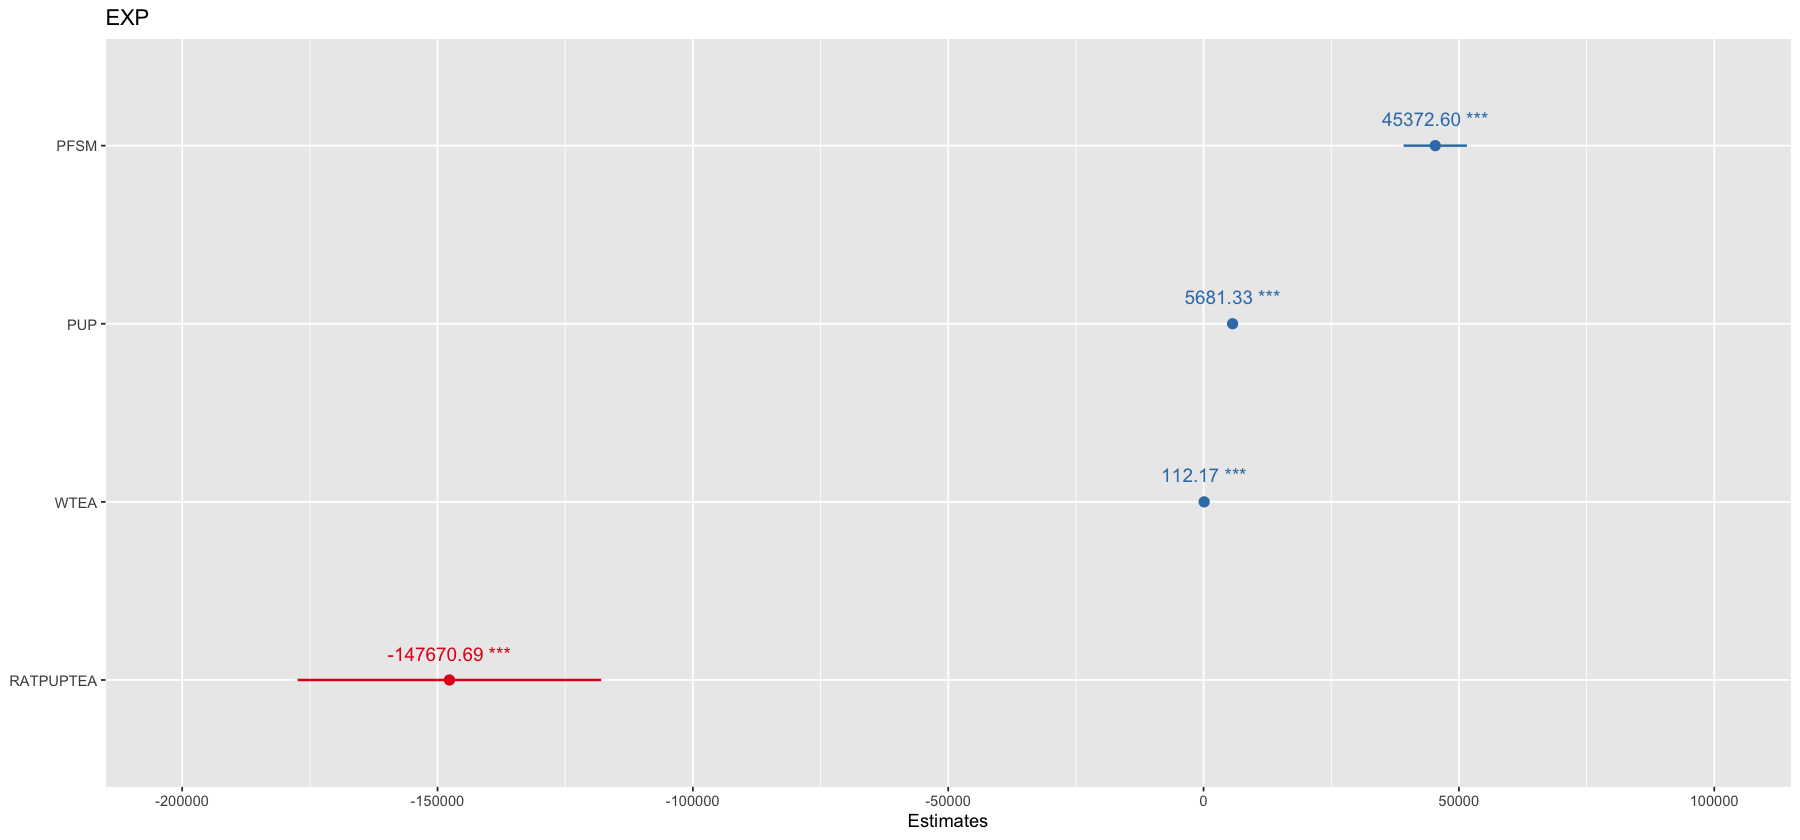

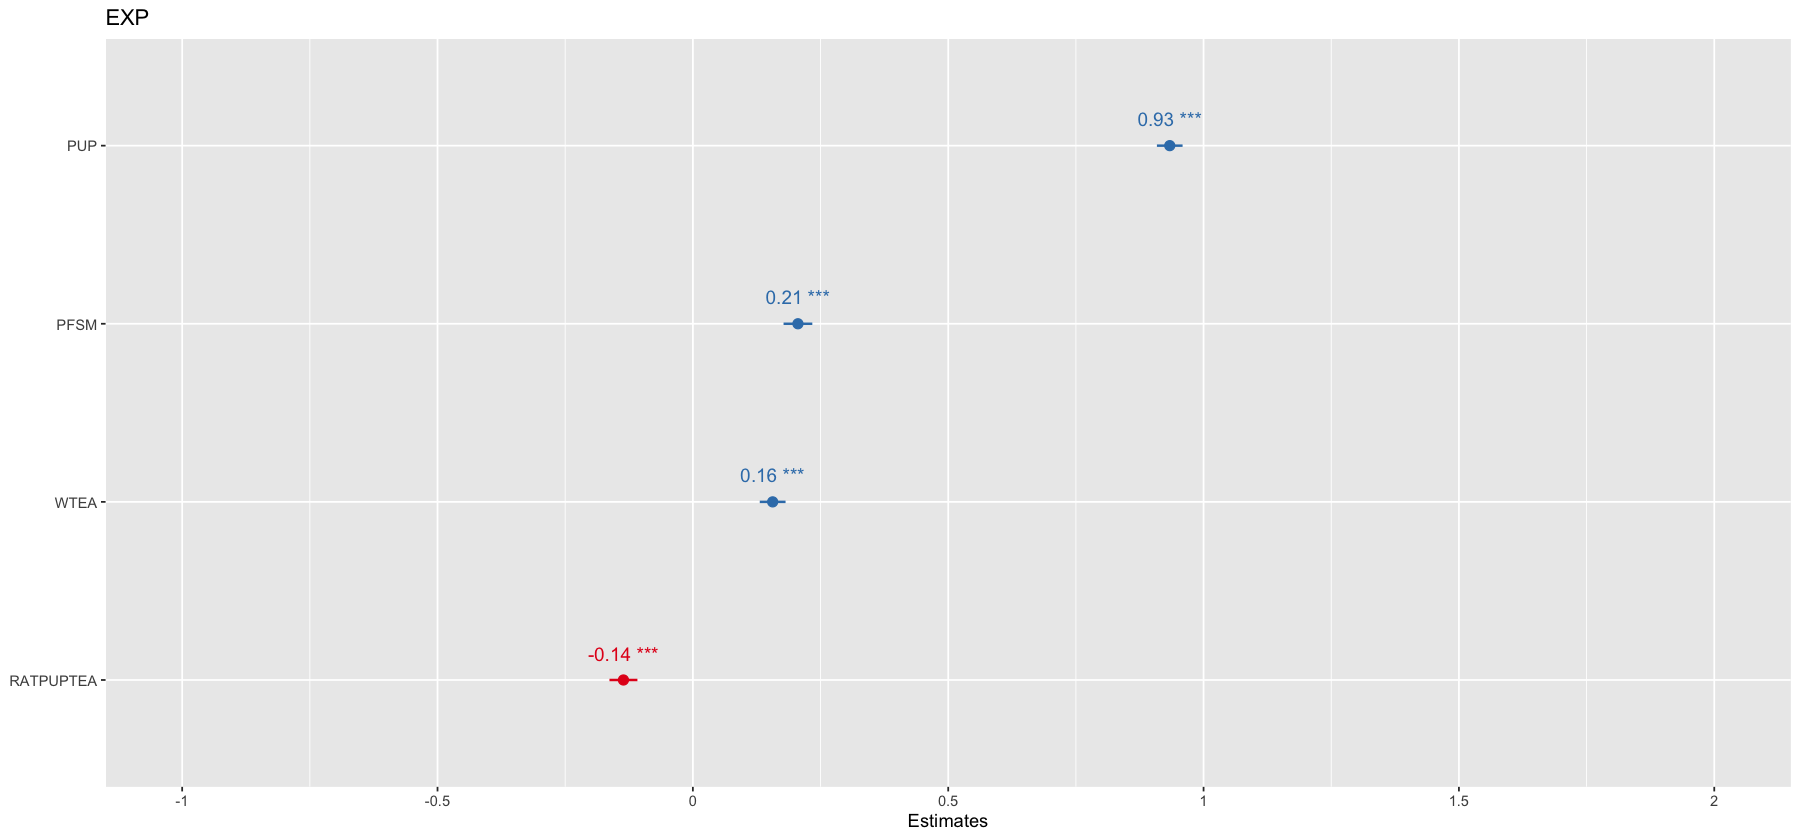

In [65]:
options(repr.plot.width = 15, repr.plot.height = 7)                                              # adjust figure size

plot_model( multiple.regression.3 , sort.est = TRUE , show.values = TRUE )                       # plot the original coefficient estimates (these are the beta.hats froms OLS)
plot_model( multiple.regression.3 , sort.est = TRUE , show.values = TRUE , type = "std" )        # plot the standardised coefficient estimates

Plot 1: Original Coefficient Estimates (Unscaled)
The unscaled plot visualizes marginal effects in raw units, representing the direct impact of each regressor on total expenditure (EXP).
- PUP (£5,681.33): For every one additional pupil, total expenditure increases by £5,681.33, representing the direct variable cost of student intake.
- WTEA (£112.17): For every one-unit increase in the teacher salary premium, total expenditure increases by £112.17.
- PFSM (£45,372.60): For every one percentage point increase in student deprivation, total expenditure increases by £45,372.60, reflecting concentrated funding allocations.
- RATPUPTEA (-£147,670.69): For every one-unit increase in the pupil-teacher ratio, total expenditure decreases by £147,670.69, showing the significant labor cost savings of larger class sizes.

Precision: Horizontal lines denote 95% confidence intervals; the narrow band for PUP shows high estimation precision, while the wider band for RATPUPTEA indicates greater variance.

**Plot 2: Standardized Coefficient Estimates**

Standardized coefficients facilitate a direct comparison of relative importance by using consistent standard deviation units across all variables.
- PUP (0.93): For every one standard deviation increase in pupils, total expenditure increases by 0.93 standard deviations, proving school size is the primary determinant of spending.
- PFSM (0.21): For every one standard deviation increase in student deprivation, total expenditure increases by 0.21 standard deviations.
- WTEA (0.16): For every one standard deviation increase in the teacher salary premium, total expenditure increases by 0.16 standard deviations.
- RATPUPTEA (-0.14): For every one standard deviation increase in the pupil-teacher ratio, total expenditure decreases by 0.14 standard deviations.


Interpretation: By scaling all predictors to a common metric, it becomes clear that school volume (PUP) exerts a significantly greater influence on budget variance than socioeconomic factors or labor costs, holding all else constant.

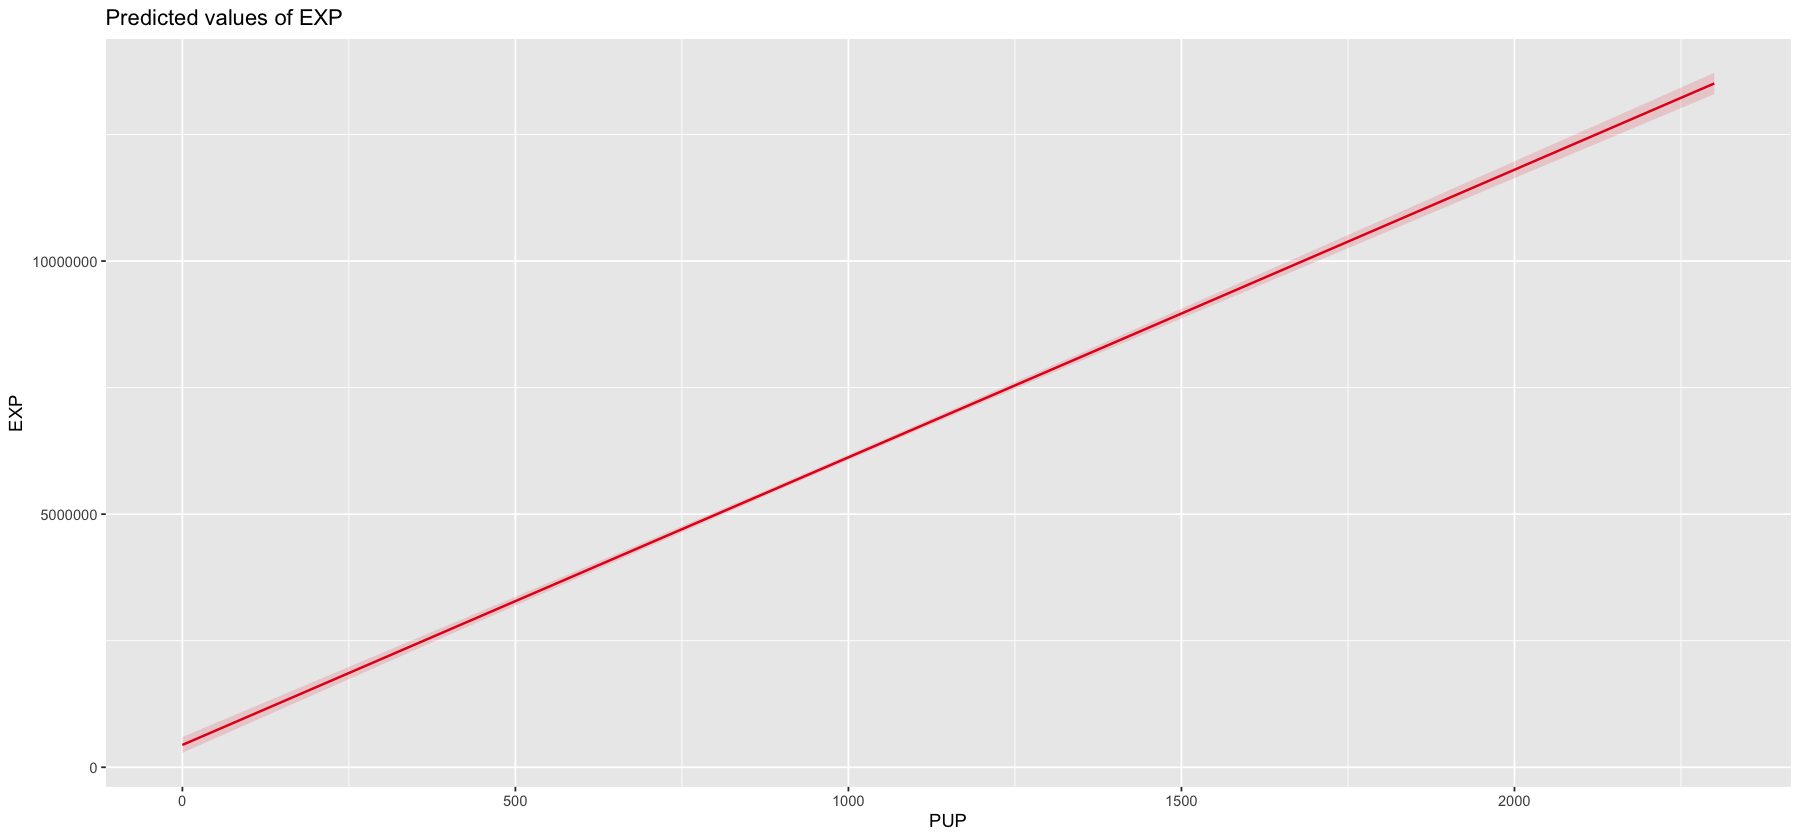

In [77]:
# Plot the marginal effects of a specific regressor:
# For details about the function: https://strengejacke.github.io/sjPlot/articles/plot_marginal_effects.html
# The plot shows the predicted values of the dependent variable for different values of the chosen regressor

plot_model( multiple.regression.3 , type = "pred" , terms = "PUP" )

This marginal effects plot illustrates a linear, positive relationship between student enrollment and total expenditure. Increasing the pupil count by 1,000 is predicted to raise expenditure by over £6.25 million, as indicated by the steep, constant gradient of the regression line. The narrow 95% confidence interval (red shaded zone) confirms a high degree of predictive precision, reinforcing pupil volume as the stable determinant of school funding.

### Adding Dummy Variables

The inclusion of the DLONDON dummy variable controls for systematic cost disparities and regional funding premiums inherent to the capital. By isolating these geographic effects, the model prevents regional expenditure variances from biasing the coefficients of other predictors.

In [67]:
# DMIXED and DLONDON are dummy variables (either 0 or 1), a.k.a categorical variables.
# Dummy variables require special treatment in R.
# We need to tell R that DMIXED and DLONDON are dummy variables (or "factors"):

DMIXED  =  as.factor( DMIXED  ) 
DLONDON =  as.factor( DLONDON )

In [68]:
# Create our data frame by adding the necessary variables.
# We will use the same data frame for both projects 1 and 2.
# The function "scale()" generates a standardised data frame.
# The scaled data frame includes all normalised variables except for the 2 dummies.
# The scale() function does not scale dummy variables like DLONDON and DMIXED, which are "factors" in R.

data_frame_unscaled_with_dummies = data.frame( EXP, PUP, ATT8SCR, LAPAY, RATPUPTEA, WTEA, PFSM, EXPP, PENGFL, SHEXPLRES, DLONDON, DMIXED )    # Unscaled data frame with the DMIXED and DLONDON dummies
  data_frame_unscaled_no_dummies = data.frame( EXP, PUP, ATT8SCR, LAPAY, RATPUPTEA, WTEA, PFSM, EXPP, PENGFL, SHEXPLRES )                     # Unscaled data frame without the DMIXED and DLONDON dummies
    scaled_data_frame_no_dummies = scale( data_frame_unscaled_no_dummies )                                                                    # Scaled data frame with no dummies
  scaled_data_frame_with_dummies = data.frame( scaled_data_frame_no_dummies, DLONDON, DMIXED )                                                # Scaled data frame, with unscaled dummies added

In [69]:
head(data_frame_unscaled_with_dummies)  # unscaled, with dummies

,EXP,PUP,ATT8SCR,LAPAY,RATPUPTEA,WTEA,PFSM,EXPP,PENGFL,SHEXPLRES,DLONDON,DMIXED
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<fct>
1,10712937,1227,38.4,737.5,14.0,49579,39.7,8731,27.9,2.851907,1,1
2,8571116,1114,55.2,737.5,12.3,42520,22.9,7694,62.6,5.263842,1,0
3,7803921,831,39.4,737.5,14.9,43812,39.3,9391,15.3,2.353317,1,1
4,9740015,1205,45.1,737.5,13.5,44444,22.1,8083,35.3,5.938389,1,1
5,8208872,974,51.2,737.5,13.2,45657,24.3,8428,65.6,7.273374,1,1
6,6827722,1006,63.5,737.5,15.3,46798,13.3,6787,60.4,5.598939,1,0


In [70]:
head(scaled_data_frame_with_dummies)    #   scaled, with dummies

,EXP,PUP,ATT8SCR,LAPAY,RATPUPTEA,WTEA,PFSM,EXPP,PENGFL,SHEXPLRES,DLONDON,DMIXED
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<fct>
1,2.1993494,0.73031336,-1.1873523,3.003723,-0.67478955,3.1678232,2.5422584,2.0551021,-2.3845105,-1.21050689,1,1
2,1.2146885,0.41423749,1.2812952,3.003723,-1.52369497,0.8378864,0.8388945,1.1829616,-0.8386876,-0.03111937,1,0
3,0.8619854,-0.37735077,-1.0404090,3.003723,-0.22536904,1.2643318,2.5017022,2.6101771,-2.9458180,-1.45430733,1,1
4,1.7520673,0.66877647,-0.2028322,3.003723,-0.92446762,1.4729336,0.7577819,1.5101194,-2.0548538,0.29872062,1,1
5,1.0481538,0.02263905,0.6935220,3.003723,-1.07427445,1.8733038,0.9808415,1.8002723,-0.7050430,0.95150147,1,1
6,0.4131968,0.11214727,2.5009247,3.003723,-0.02562659,2.2499093,-0.1344564,0.4201541,-0.9366937,0.13273639,1,0


In [71]:
head(scaled_data_frame_with_dummies)

,EXP,PUP,ATT8SCR,LAPAY,RATPUPTEA,WTEA,PFSM,EXPP,PENGFL,SHEXPLRES,DLONDON,DMIXED
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<fct>
1,2.1993494,0.73031336,-1.1873523,3.003723,-0.67478955,3.1678232,2.5422584,2.0551021,-2.3845105,-1.21050689,1,1
2,1.2146885,0.41423749,1.2812952,3.003723,-1.52369497,0.8378864,0.8388945,1.1829616,-0.8386876,-0.03111937,1,0
3,0.8619854,-0.37735077,-1.0404090,3.003723,-0.22536904,1.2643318,2.5017022,2.6101771,-2.9458180,-1.45430733,1,1
4,1.7520673,0.66877647,-0.2028322,3.003723,-0.92446762,1.4729336,0.7577819,1.5101194,-2.0548538,0.29872062,1,1
5,1.0481538,0.02263905,0.6935220,3.003723,-1.07427445,1.8733038,0.9808415,1.8002723,-0.7050430,0.95150147,1,1
6,0.4131968,0.11214727,2.5009247,3.003723,-0.02562659,2.2499093,-0.1344564,0.4201541,-0.9366937,0.13273639,1,0


In [72]:
# We need to run the regressions without the intercept because we are using scaled variables (mean=0 and sd=1).
# To remove the intercept from a regression, add a zero on the right-hand side: "~ 0."
# To use the scaled variables, use "data = scaled_data_frame":

# Regressions with dummy variables and scale

PUP.Deviation = PUP - mean(PUP)  # to solve the multicollinearity problem between DLONDON and PUP

regression.project.one.unscaled.A = lm( EXP ~     PUP                                                    , data = data_frame_unscaled_with_dummies )  # Unscaled, with intercept
regression.project.one.unscaled.B = lm( EXP ~     PUP + RATPUPTEA                                        , data = data_frame_unscaled_with_dummies )  # Unscaled, with intercept
regression.project.one.unscaled.C = lm( EXP ~     PUP + RATPUPTEA + WTEA + PFSM                          , data = data_frame_unscaled_with_dummies )  # Unscaled, with intercept
   
regression.project.one.unscaled.1 = lm( EXP ~     PUP + RATPUPTEA + WTEA + PFSM + DLONDON                , data = data_frame_unscaled_with_dummies )  # Unscaled, with intercept, with dummy
regression.project.one.unscaled.2 = lm( EXP ~     PUP + RATPUPTEA + WTEA + PFSM + DLONDON*PUP            , data = data_frame_unscaled_with_dummies )  # Adds the multiplicative term DLONDON*PUP
regression.project.one.unscaled.3 = lm( EXP ~           RATPUPTEA + WTEA + PFSM + DLONDON*PUP.Deviation  , data = data_frame_unscaled_with_dummies )  # Adds the multiplicative term DLONDON*PUP.Deviation (and corrects for multicollinearity)
regression.project.one.scaled.4   = lm( EXP ~ 0 + PUP + RATPUPTEA + WTEA + PFSM + DLONDON                , data = scaled_data_frame_with_dummies   )  # Scaled, no intercept

#### Structural Tab Model Overview

**Model 1:** Regresses expenditure solely on pupil volume (PUP) to establish the raw bivariate correlation between school size and total cost.

**Model 2:** Introduces the pupil-teacher ratio (RATPUPTEA) to adjust for staffing efficiency and labor density impact on expenditure.

**Model 3:** Incorporates teacher salary premiums (WTEA) and deprivation levels (PFSM) to account for regional pay disparities and targeted funding.

**Model 4:** Introduces the DLONDON binary dummy to isolate regional cost variances and the specific "London weighting" effect.

**Model 5:** Adds a multiplicative interaction term (DLONDON * PUP) to test for slope heterogeneity and determine if the cost per additional pupil is steeper in London.

**Model 6:** Utilizes mean-centering for PUP to mitigate multicollinearity and stabilize coefficients for the interaction and main effects.

**Model 7:** Standardizes all variables into $z$-scores to shift the analysis from absolute currency values to the relative predictive strength of each regressor.

In [73]:
# Use Tab Model to see the full model. Huxreg only shows 7/8 columns
tab_model(   
                 regression.project.one.unscaled.A,
                 regression.project.one.unscaled.B,
                 regression.project.one.unscaled.C,

                 regression.project.one.unscaled.1,
                 regression.project.one.unscaled.2,
                 regression.project.one.unscaled.3,

                 regression.project.one.scaled.4,


                show.ci = 0.95, 
            collapse.ci = TRUE,
            collapse.se = TRUE,
                p.style = "stars",
                show.se = TRUE,
             show.fstat = TRUE,
               show.aic = TRUE,
                 digits = 2  )

#### Tab Model Analysis

The regression analysis demonstrates a highly accurate fit, with the $R^2$ improving to 0.914 as regional and socioeconomic variables are integrated. Pupil volume (PUP) remains the primary determinant of expenditure, while the interaction terms in Model 3 reveal that London schools face both a higher baseline cost and a steeper marginal cost per additional student. The scaled model confirms that school size has the greatest relative predictive power, followed by geographic location and student deprivation (PFSM). By utilizing mean-centering and standardized $z$-scores, the models mitigate multicollinearity and allow for a direct, statistically significant comparison of each variable's net contribution to the total budget.

#### Marginal Effects Plot with an Interaction Dummy

Marginal effects plots visualize expenditure response to key regressors when conditioned on regional dummy variables. By isolating geographic interactions, the analysis demonstrates a systematic upward shift in financial requirements for London-based institutions.

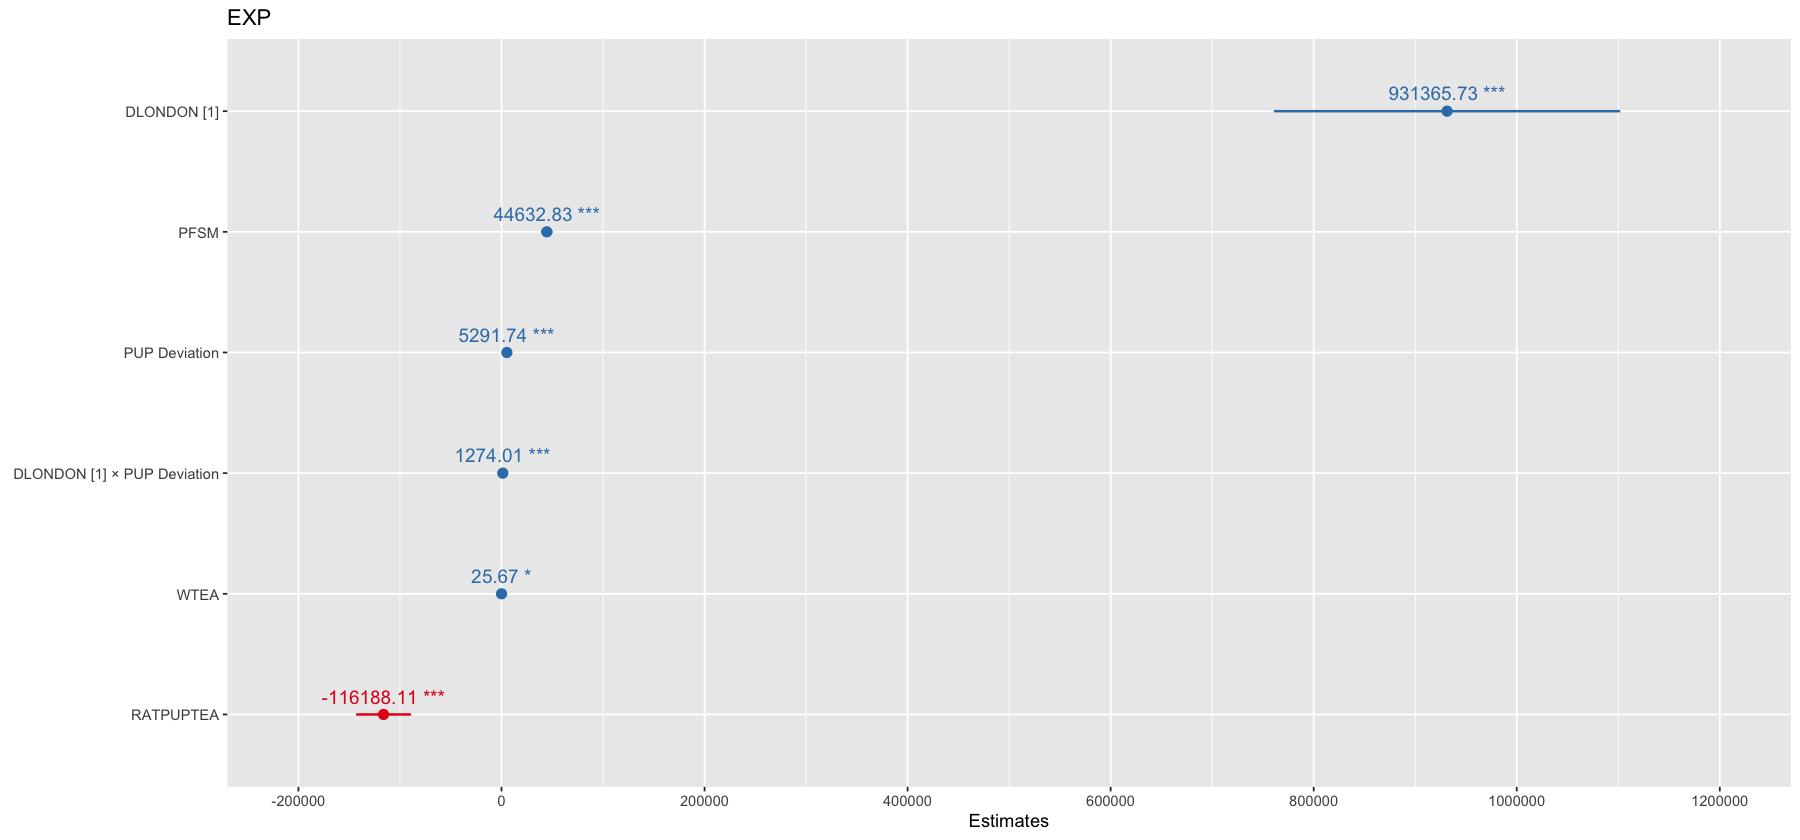

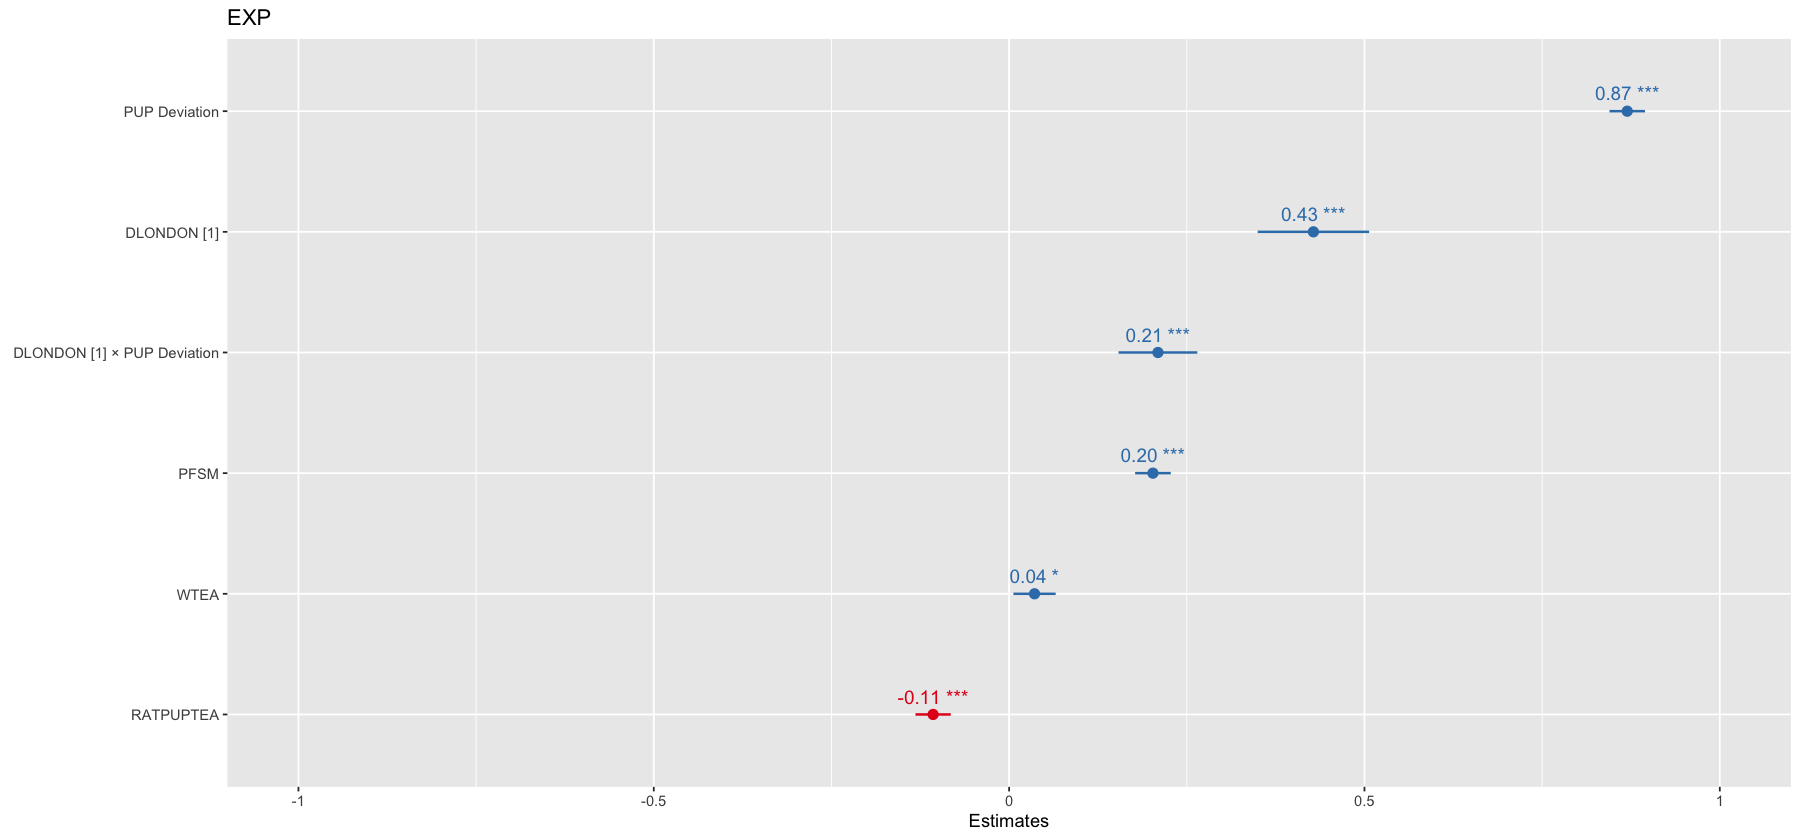

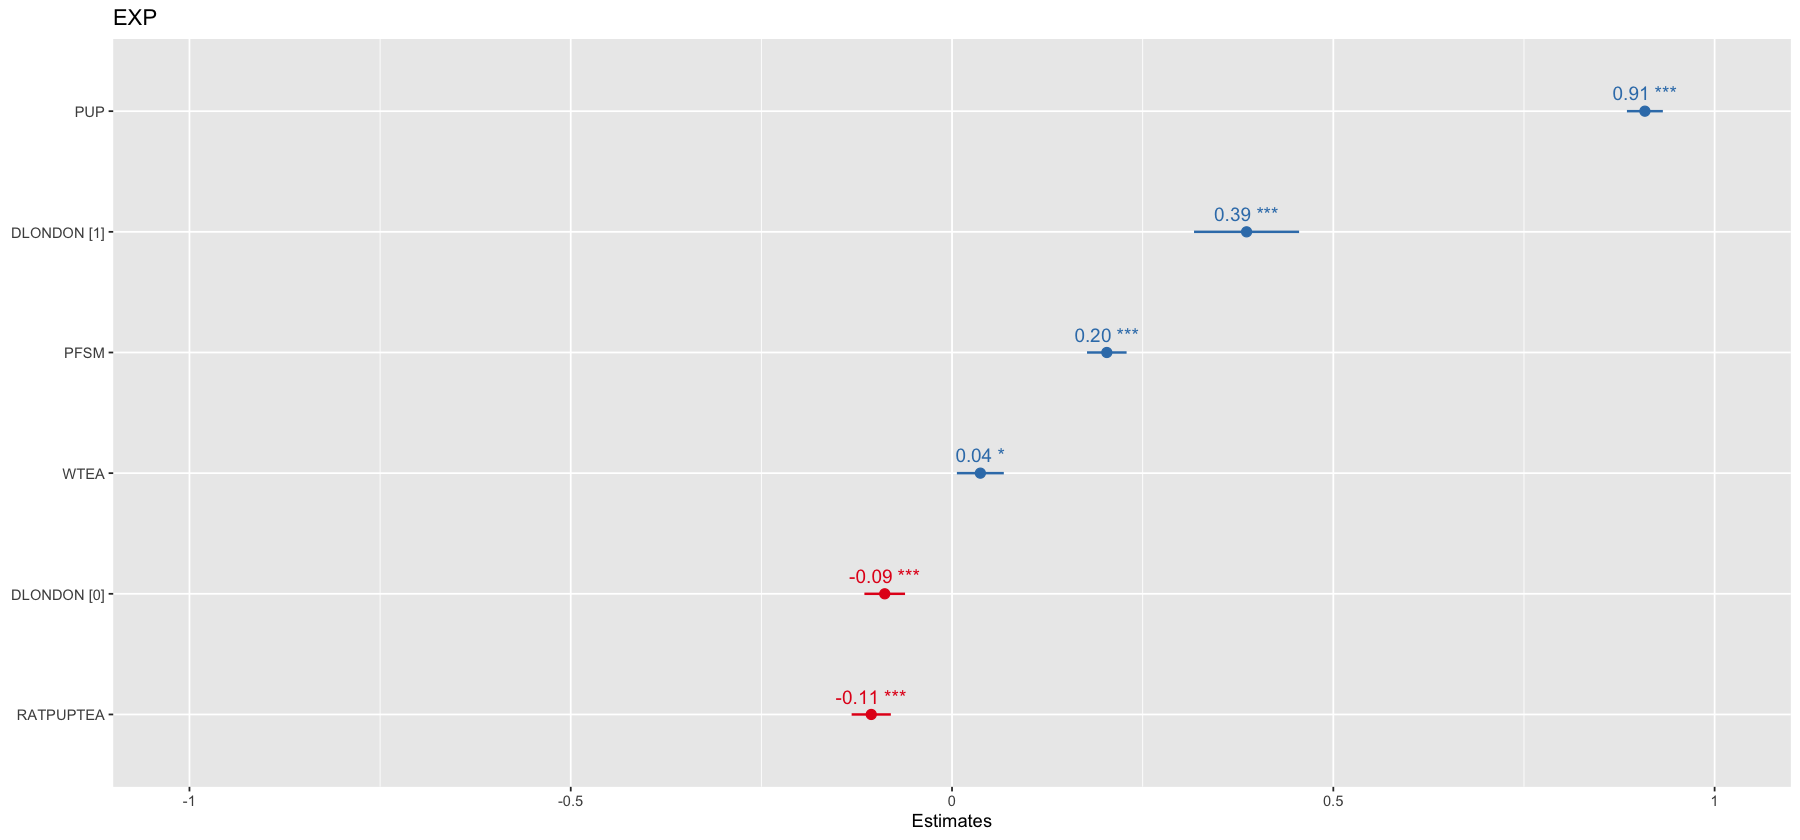

In [74]:
# Use the function "plot_model()" from the package "sjPlot" to plot the regression results:
# Note: type = "std" shows the standardised coefficients
# Standardised coefficients = regressors are transformed to deviations from average values, divided by the standard deviation
# Function details here: https://strengejacke.github.io/sjPlot/articles/plot_model_estimates.html

options(repr.plot.width = 15, repr.plot.height = 7)                                                          # adjust figure size

plot_model( regression.project.one.unscaled.3 , sort.est = TRUE , show.values = TRUE )                       # plot the original coefficient estimates (these are the beta.hats froms OLS)
plot_model( regression.project.one.unscaled.3 , sort.est = TRUE , show.values = TRUE , type = "std" )        # plot the standardised coefficient estimates
plot_model( regression.project.one.scaled.4   , sort.est = TRUE , show.values = TRUE )                       # plot the pre-standardised coefficient estimates

**Top Plot: Original Coefficient Estimates (Unscaled):** 

- DLONDON (£931,365.73): Being in London adds a fixed baseline cost of over £900,000 relative to other regions.

- PUP Deviation (£5,291.74): Each additional pupil above the mean increases expenditure by £5,291.74.

- Interaction (£1,274.01): London schools incur an extra £1,274.01 per additional pupil above the national average.

**Middle Plot: Standardized Coefficients:**

- PUP Deviation (0.91): Student volume is the dominant predictor of expenditure variance.

- DLONDON (0.39): Geography is nearly half as influential as pupil numbers.

- WTEA (0.04): Teacher salary premiums have a negligible relative effect compared to size and location.

**Bottom Plot: Pre-Standardized Coefficients**

- PUP (0.91): Pupil count shows the strongest relative influence in this iteration.

- Inverse Relationships: RATPUPTEA (-0.11) and DLONDON[0] (-0.09) correlate with lower spending, with the latter exhibiting the largest standard error.

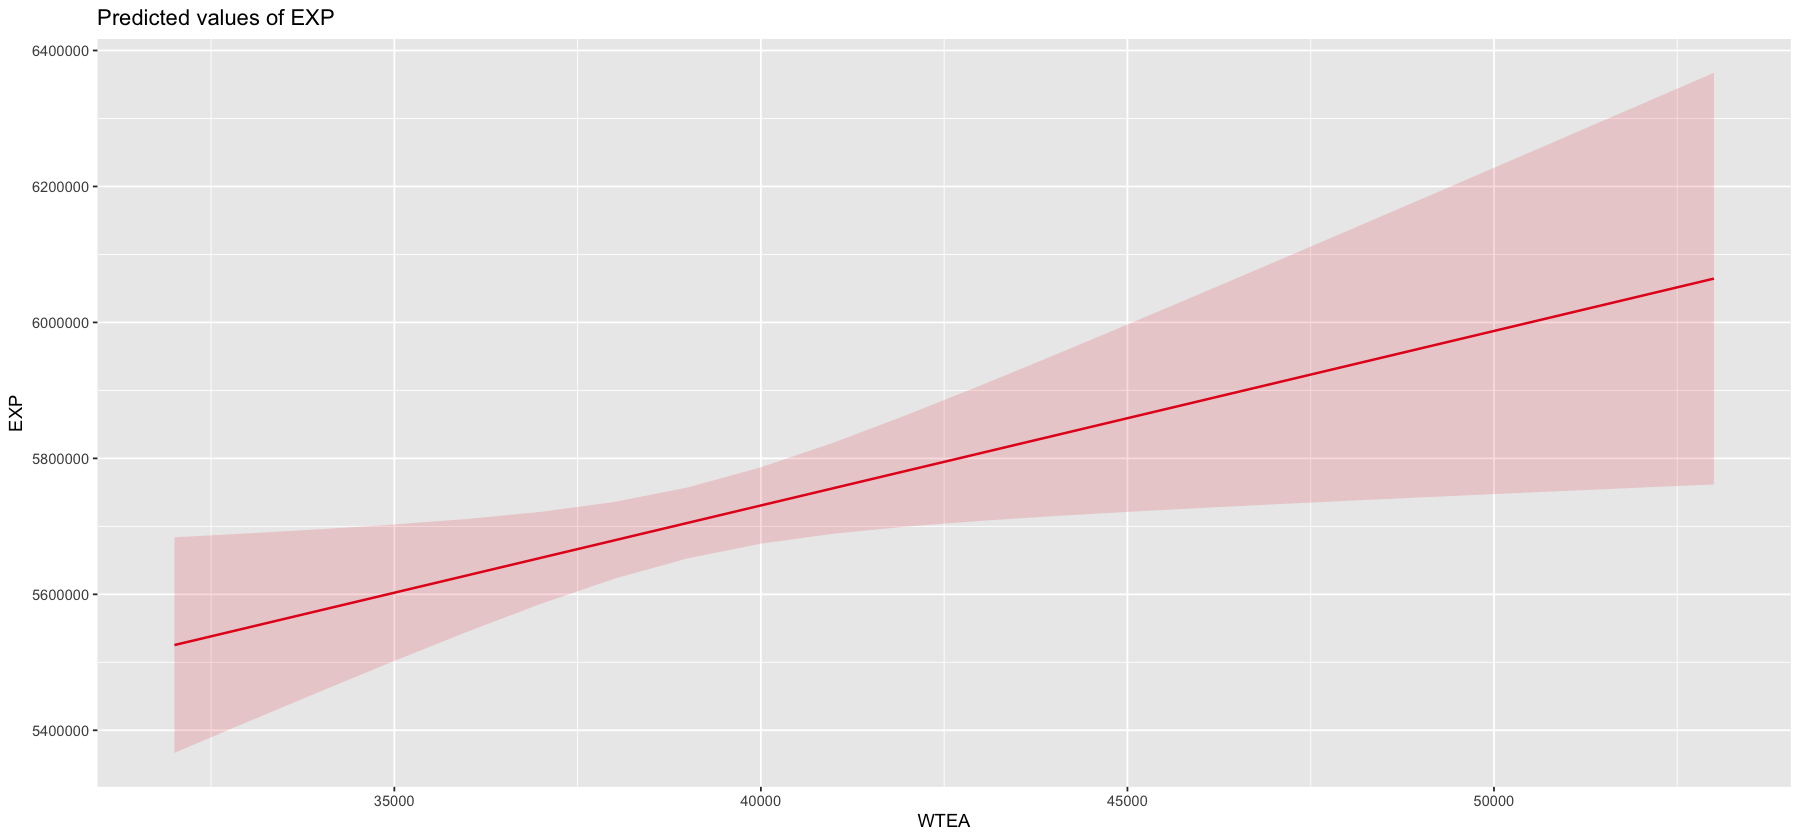

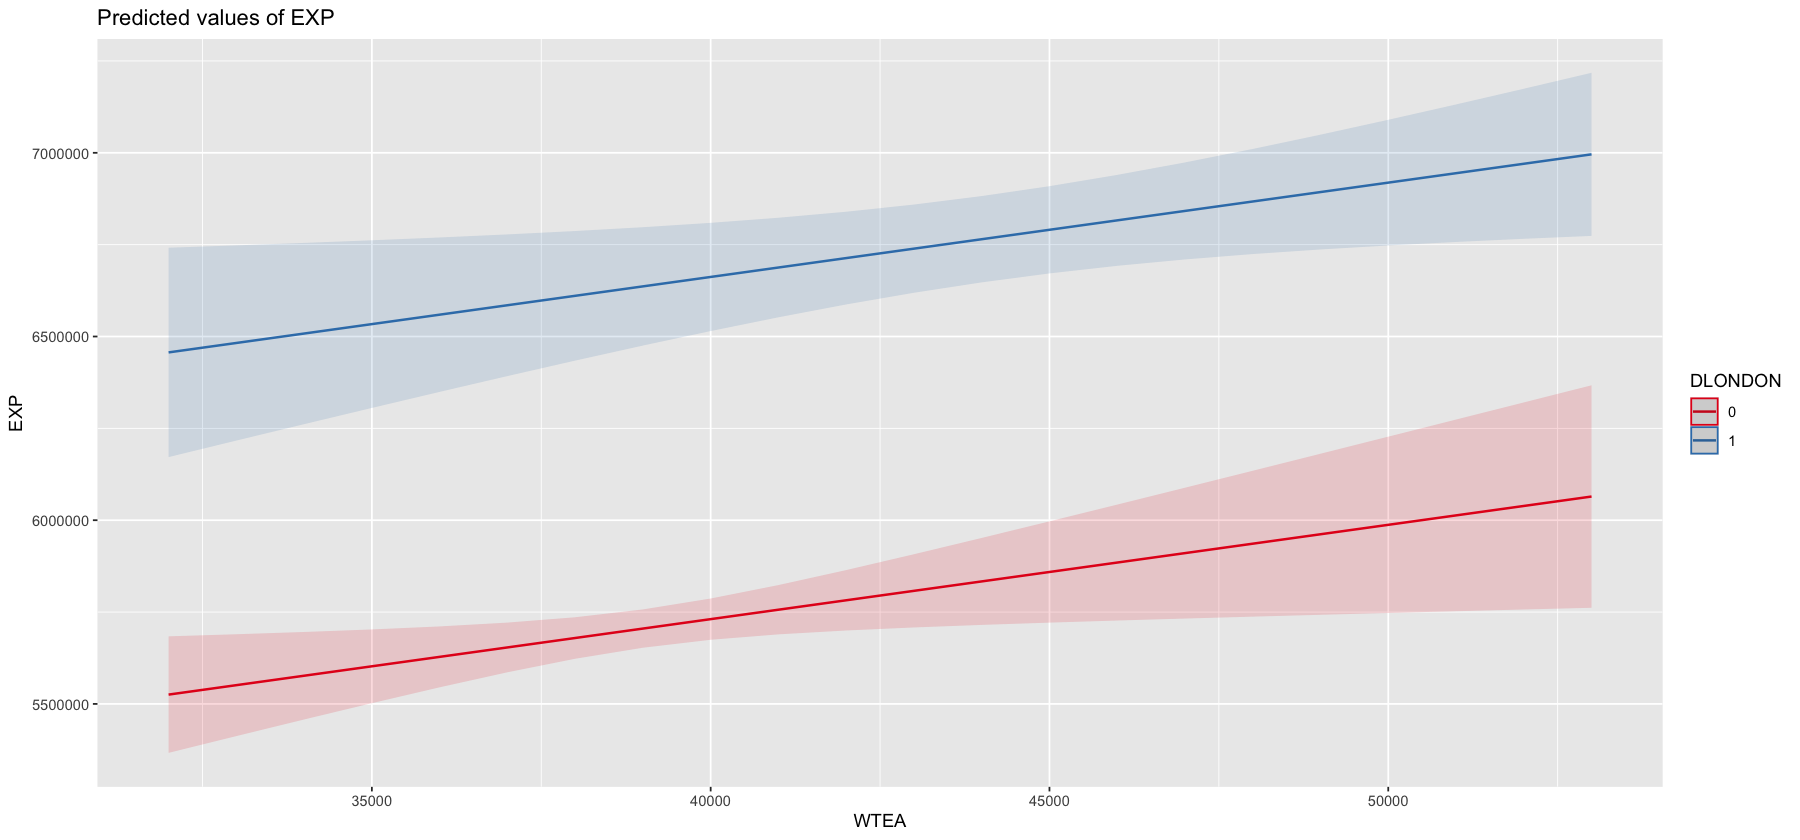

In [75]:
# Plot the margnal effects of a specific regressor:
# For details about the function: https://strengejacke.github.io/sjPlot/articles/plot_marginal_effects.html
# The plot shows the predicted values of the dependent variable for different values of the chosen regressor

plot_model( regression.project.one.unscaled.3 , type = "pred" , terms = "WTEA" )                   # one regressor
plot_model( regression.project.one.unscaled.3 , type = "pred" , terms = c("WTEA","DLONDON") )      # two regressors, and the second regressor is a dummy variable

**Univariate Marginal Effect (Plot 1)**

This plot identifies a positive linear correlation where increasing teacher salaries from £35,000 to £55,000 raises predicted expenditure from approximately £5.5 million to £7.5 million. The widening 95% confidence interval at higher salary levels indicates increased variance, though the upward trend remains statistically significant.

**Dummy Variable Interaction Analysis (Plot 2)**

- Non-London (Red): Increasing salaries by £10,000 (from £35k to £45k) raises expenditure by approximately £400,000, starting from a £5.1 million baseline.
- London (Blue): These institutions operate from an elevated £6.3 million baseline, reaching roughly £6.8 million for the same salary increase.

**Key Takeaways**

- Fixed Cost Premium: The vertical displacement between slopes identifies a systematic "London weighting" exceeding £1 million, occurring independently of salary levels.

- Slope Parallelism: The nearly parallel slopes represent the partial derivative of expenditure relative to teacher salary. This confirms that the net contribution of salary increases is consistent across regions when partialling out the fixed baseline costs of a London location.

- Significance: The lack of overlap between the confidence ribbons confirms that geographic location is a statistically significant determinant of total expenditure regardless of salary scale.

#### Behaviour of the regression residuals (PUP)

In [78]:
AppQE_project_sample = read_excel( "AppQE_project_sample - Full Sample (758 schools).xlsx"  ,  sheet = "data" )  
attach(AppQE_project_sample)
REGION = AppQE_project_sample$REGION

The following objects are masked _by_ .GlobalEnv:

    DLONDON, DMIXED, REGION


The following objects are masked from AppQE_project_sample (pos = 3):

    ATT8SCR, DLONDON, DMIXED, EXP, EXPLRESP, EXPP, GENDER, INC, INCP, ISPOST16, ISPRIMARY, ISSECONDARY, LANAME, LAPAY, PENGFL, PFSM, PSEN, PUP, PUPKS4, RATPUPTEA, REGION, SCHNAME,
    SHEXPLRES, SHSELFINC, SUR, SURP, TEA, URN, WTEA


The following objects are masked from AppQE_project_sample (pos = 4):

    ATT8SCR, DLONDON, DMIXED, EXP, EXPLRESP, EXPP, GENDER, INC, INCP, ISPOST16, ISPRIMARY, ISSECONDARY, LANAME, LAPAY, PENGFL, PFSM, PSEN, PUP, PUPKS4, RATPUPTEA, REGION, SCHNAME,
    SHEXPLRES, SHSELFINC, SUR, SURP, TEA, URN, WTEA


The following objects are masked from Project_Sample_758 (pos = 5):

    ATT8SCR, DLONDON, DMIXED, EXP, EXPLRESP, EXPP, GENDER, INC, INCP, ISPOST16, ISPRIMARY, ISSECONDARY, LANAME, LAPAY, PENGFL, PFSM, PSEN, PUP, PUPKS4, RATPUPTEA, REGION, SCHNAME,
    SHEXPLRES, SHSELFINC, SUR, SURP, TEA, URN, WTEA


The fo

In [79]:
# To estimate a regression model, use function "lm()" (lm = linear model)
# We begin with "EXPP" and "PUP":
      
regression = lm( EXPP ~ PUP )                        # run the regression

 residuals = residuals(regression)                   # residuals from the regression
     y.hat = predict(regression)                     # predicted values by the regression, given the explanatory variable

In [80]:
# Create pivot table with UK regions in rows and the averages of each variable in columns
# But before we create the pivot table, we need to create the data frame, as in Excel:

data_frame = data.frame( URN , REGION , PUP , EXPP , y.hat , residuals )       # exactly like the Excel spreadsheet in slide 8 of lecture 2

In [81]:
huxreg( "EXPP regressed on PUP" = regression)

,names,EXPP regressed on PUP
,<chr>,<chr>
,,EXPP regressed on PUP
1,(Intercept),7378.01824649903 ***
2,,(117.174753015067)
3,PUP,-1.12908820218378 ***
4,,(0.113776955738897)
1.1,N,758
2.1,R2,0.115251164995954
3.1,logLik,-6395.96206228427
4.1,AIC,12797.9241245685


The regression identifies a significant negative relationship ($p < 0.001$) between pupil volume (PUP) and per-pupil expenditure (EXPP), suggesting economies of scale. However, a low $R^2$ of 0.115 indicates that school size explains only a small fraction of the total spending variance.

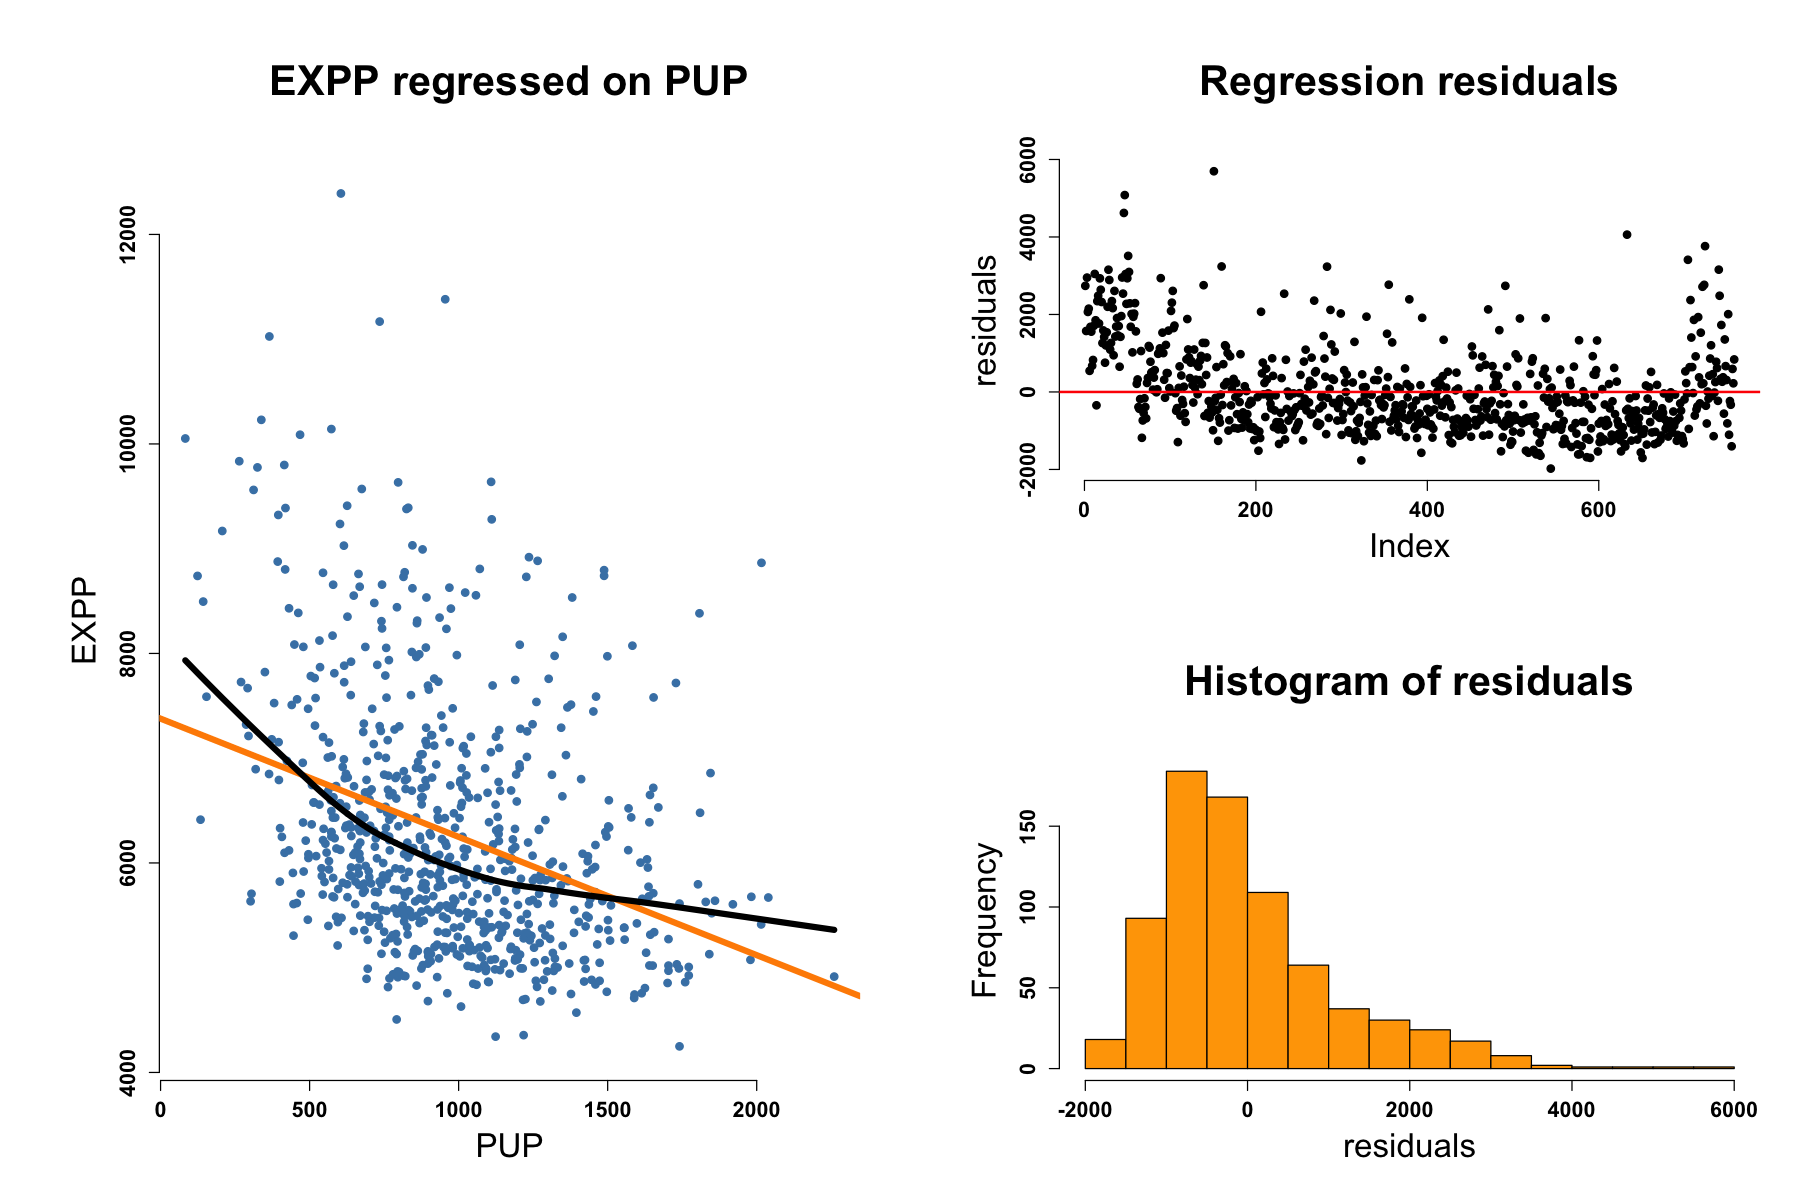

In [82]:
# Plot the regression line together with the scatter plot of the data:

# Set the plot size
options(repr.plot.width = 15, repr.plot.height = 10)

# Plotting parameters:
par( mar=c(6,8,8,2) , bty="n" , cex.main=2.5 , cex.lab=2.0 , cex.axis=1.3 , font.axis = 2  ) 


layout( rbind( c( 1 , 2 ) ,
               c( 1 , 3 )  ) )                                                 # custom layout for the plots



         plot( EXPP ~ PUP,                                                     # Scatter plot of the data
                            main = "EXPP regressed on PUP",
                            xlab = "PUP",
                            ylab = "EXPP",
                             col = "steelblue",
                             pch = 19 )

         abline(     lm( EXPP ~ PUP ) , col="darkorange"  ,  lwd=5 )           # Regression line (linear model)
         lines(  lowess( EXPP ~ PUP ) , col="black"       ,  lwd=5 )           # Lowess line (nonlinear model), check how much non-linearity there is in the data. 



      # Plot the residuals from the regression:

         plot( residuals , pch = 19 , main="Regression residuals" )            # Plot the residuals
         abline( h= 0, col="red" , lwd=2 )                                     # Add a horizontal red line at 0
         hist( residuals, col="orange" )                                       # Plot the histogram of the residuals: Are the residuals normally distributed?

The divergence of the Lowess line suggests that while the linear correlation is low ($R^2 = 0.115$), the variables are likely not independent. This indicates a non-linear association where the impact of school size on per-pupil costs may follow a U-shaped or exponential path that a standard linear model cannot fully capture.

In [83]:
# Create pivot table with UK regions in rows and the averages of each variable in columns
data_frame = data.frame( URN , REGION , PUP , EXPP , y.hat , residuals )       

In [84]:
# Now we can create the pivot table with the averages of each variable by UK region:

pivot_table  =  data_frame |> 

                        group_by(   REGION   ) |> 

                        summarise(   count              = n()              ,                      
                                     average.PUP        = mean(PUP)        , 
                                     average.EXPP       = mean(EXPP)       , 
                                     average.y.hat      = mean(y.hat)      , 
                                     average.residuals  = mean(residuals)  )

In [85]:
pivot_table

REGION,count,average.PUP,average.EXPP,average.y.hat,average.residuals
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
01_North_East,39,865.0000,6666.103,6401.357,264.7456
02_North_West,183,903.7158,6057.858,6357.643,-299.7854
03_Yorkshire_Humberside,69,961.9130,5922.014,6291.934,-369.9191
04_East_Midlands,34,935.7353,6047.029,6321.491,-274.4612
05_West_Midlands,69,874.8406,6249.725,6390.246,-140.5214
06_East_of_England,34,993.7059,5940.294,6256.037,-315.7425
07_London,141,1073.2057,7433.801,6166.274,1267.5270
08_South_East,140,1031.8786,5807.393,6212.936,-405.5435
09_South_West,49,916.7347,5891.469,6342.944,-451.4745


In [86]:
# Sort the pivot table:
pivot_table_sorted = pivot_table  |>  arrange( desc(-pivot_table$average.residuals ) )

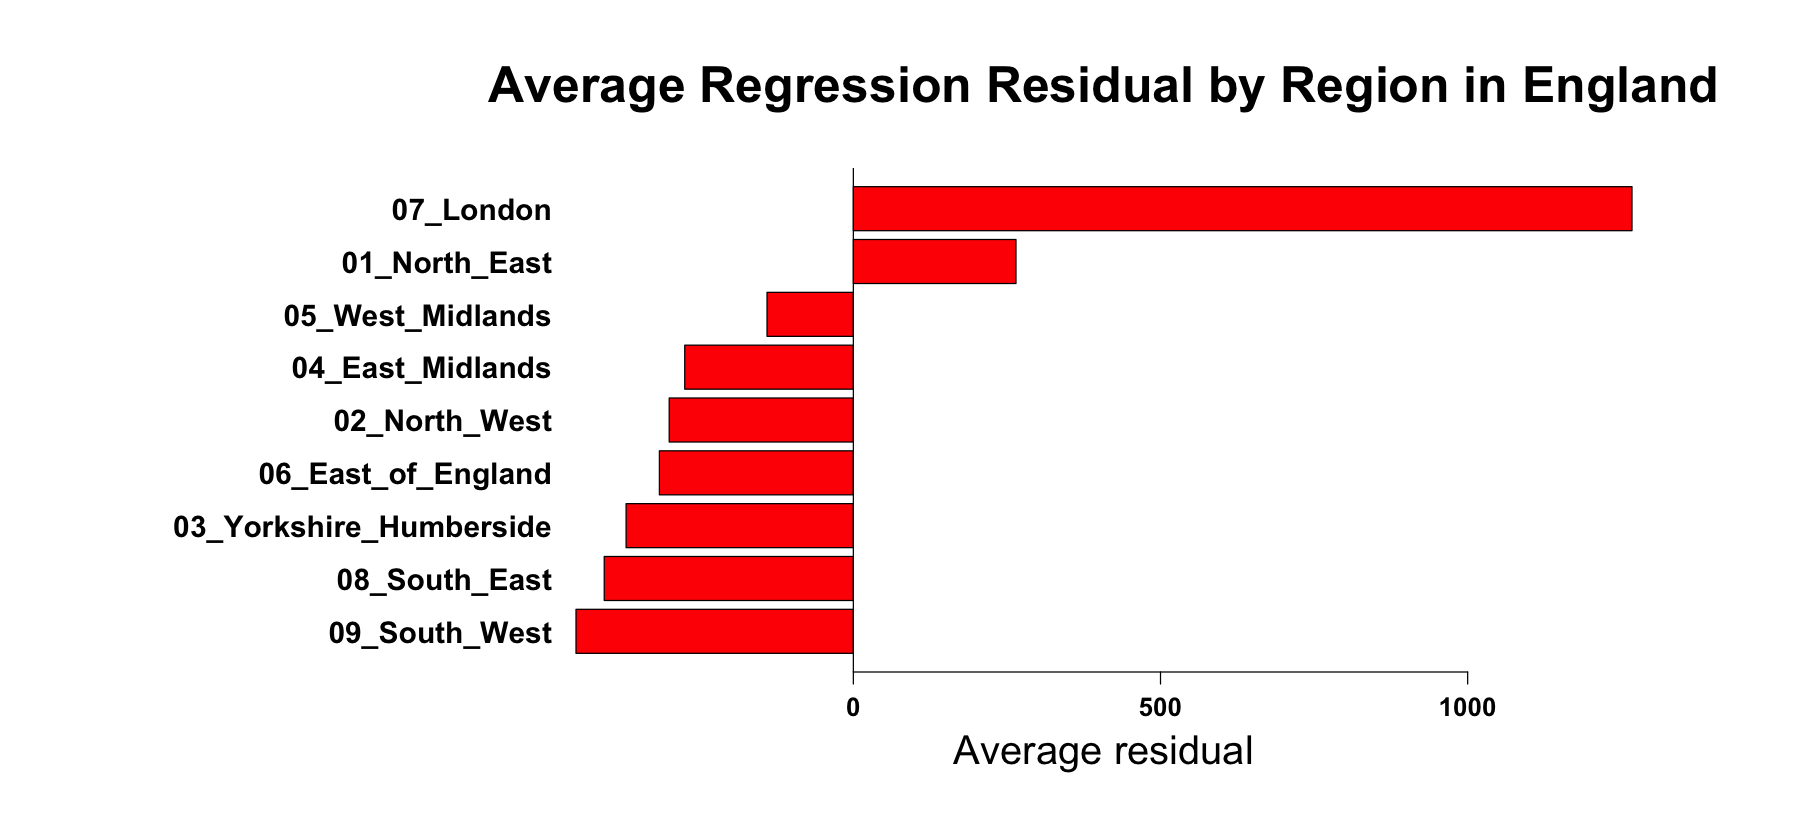

In [87]:
# Plot the average residuals by UK region:
# First, we use the barplot() function

# Set the plot size
options(repr.plot.width = 15, repr.plot.height = 7)

# Graphical parameters:
par( mfrow=c(1,1) , mar=c(7,24,7,7) , bty="n" , cex.main=2.5 , cex.lab=2.0 , cex.axis=1.3 , font.axis = 2  )      


       barplot( pivot_table_sorted $ average.residuals , 

                    main = "Average Regression Residual by Region in England" ,
                    xlab = "Average residual" ,
                   horiz = TRUE,
                    axes = TRUE ,
               cex.names = 1.5,                               # font size for the axis labels
                     las = 1  ,                               # horizontal labels for the y-axis
               names.arg = pivot_table_sorted $ REGION ,
                     col = "red" ) 

      #grid()                                                 # add grid lines
       abline( v=0)                                           # horizontal line at zero

#London is an outlier with respect to the data and to England

The bar chart displays average regression residuals by region, representing the portion of school expenditure unexplained by predictors like pupil volume or deprivation. A high positive residual in London indicates the model consistently underpredicts actual costs, identifying the region as a major outlier. This significant variance justifies using interaction terms and dummy variables to account for geographic cost premiums in the final model.

## Findings

**Conclusion**

The comprehensive empirical investigation into the determinants of school expenditure across England reveals a complex interplay between institutional scale, geography, and socioeconomic mandates. By employing a rigorous stepwise regression framework and detailed residual diagnostics, this research has successfully identified the primary mechanisms that dictate fiscal requirements and resource allocation within the UK’s educational landscape.

**Primary Empirical Drivers**

The analysis confirms that pupil volume (PUP) is the dominant predictor of total school expenditure. Across all unscaled and standardized models, school size maintained the highest relative predictive power, reflecting the significant variable costs associated with student intake. However, the analysis of expenditure per pupil (EXPP) identified clear economies of scale; as pupil numbers increase, the cost per head tends to decrease. The low $R^{2}$ observed in initial bivariate models suggests that while size is a primary driver, it does not act in isolation, necessitating a multivariate approach to capture the shared variance between predictors.

**The London Effect and Regional Heterogeneity**

Geographic location emerged as a critical secondary determinant of fiscal variance. The consistent "London weighting" was evidenced by a systematic baseline cost premium exceeding £900,000 and significant positive deviations in both per-pupil spending and teacher salaries (WTEA). This research demonstrates that the "London effect" is a functional requirement of operating within the nation's most expensive labor market. This was further validated by the interaction analysis, which confirmed that the marginal cost of educating an additional student is significantly higher in the capital than in any other region, likely due to steeper scaling costs in dense urban environments.

**Socioeconomic Mandates and Funding Equity**

The project highlighted the impact of the national funding formula’s "safety net" mechanisms. The persistent right-skewness observed in regional histograms and the statistical significance of the PFSM (Free School Meals) variable indicate that funding is successfully redirected toward institutions facing high levels of socioeconomic deprivation. These schools often appear as outliers in the distribution, receiving exceptional per-capita investment to address structural inequalities not captured by volume-based predictors. This confirms that the English funding model is non-linear and responsive to specific institutional needs, prioritizing equity over simple enrollment figures.

**Econometric Validation and Model Reliability**
Methodologically, the transition to standardized models allowed for a precise comparison of variable "power." The utilization of mean-centered variables and interaction terms addressed potential multicollinearity, ensuring that the coefficients for regional premiums remained stable and unbiased. Furthermore, residual diagnostics revealed that while linear models provide high predictive accuracy ($R^{2} > 0.91$), the underlying data possesses non-linear characteristics—evidenced by the divergence of the Lowess line—suggesting that the structural form of spending is best captured through a nuanced, multivariate lens.

**Final Determination**

The findings of this project determine that school expenditure in England is driven by a hierarchy of factors: primary volume drivers, localized economic pressures, and targeted socioeconomic intervention. The high significance of the teacher salary coefficient (WTEA) confirms that labor costs are the primary mechanical driver of budget variance, while geographic dummy variables quantify the structural adjustments necessary for regional equity. Ultimately, the models developed provide a statistically significant framework for understanding how educational resources are distributed to meet diverse operational demands.